<span style="color:steelblue; text-align: left">

# Customer Segmentation and Next Best Action
</span>

**Data Scientist**: Enio Rubens

A portfolio project using the **Online Retail II** dataset [Chen, 2012]. The analysis transforms transactional data into customer segments using RFM and K-Means, common practices in data mining applied to retail and CRM [Chen, Sain and Guo, 2012; Jain, 2010], and adds a predictive and prescriptive layer of **Next Best Action** driven by repurchase probability, incentive simulation and expected profit, aligned with the prescriptive analytics framework [Bertsimas and Kallus, 2019].

<span style="color:steelblue; text-align: left">

## Introduction
</span>

Not all customers hold the same value for the business. Some buy frequently, others concentrate high value in few purchases, and part of the customer base goes long periods without buying. This heterogeneity is one of the foundations of market segmentation and analytical CRM [Wedel and Kamakura, 2000; Rust and Verhoef, 2005].

Segmentation helps identify groups with similar patterns and enables transforming transactional data into marketing, retention and CRM actions [Wedel and Kamakura, 2000]. This project uses RFM, a behavioral representation widely used to relate purchase history, customer value and relationship decisions [Fader, Hardie and Lee, 2005; Chen, Sain and Guo, 2012]:

- **Recency:** time since last purchase.
- **Frequency:** purchase frequency.
- **Monetary:** amount spent by the customer.

<span style="color:steelblue; text-align: left">

## Business Objective
</span>

The objective is to create an actionable view of the customer base: identify high-value groups, loyal customers, occasional buyers, at-risk customers and low-priority profiles. The final output should support investment prioritization, campaigns and customer relationship management, connecting descriptive analysis to operational decisions, as advocated in personalized CRM and prescriptive analytics approaches [Rust and Verhoef, 2005; Bertsimas and Kallus, 2019].


<span style="color:steelblue; text-align: left">

## 1. Imports & Configuration
</span>

All operational parameters are centralized in the cell below.
To re-run the notebook with a different scenario — new period, different
budget or number of segments — edit only that cell and run
`Kernel → Restart & Run All`.


In [1]:
from src.multilang import set_language; set_language("en")
from io import StringIO
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.multilang import set_language, t
from src.config import (
    DATA_PATH, EXPORT_PATH, RANDOM_STATE, N_CLUSTERS,
    PREDICTION_HORIZON_DAYS, HOLDOUT_FRACTION,
    BUDGET_TOTAL, MARGIN_RATE, INCENTIVE_CATALOGUE,
    SEGMENT_UPLIFT_MULTIPLIER,
)
from src.data import load_raw, clean, build_rfm
from src.segmentation import (
    KMeansClusterAdder, search_k, segment_names, validate_segment_names, rank01,
)
from src.prediction import (
    make_preprocessor, make_model_specs, make_repurchase_pipeline,
    evaluate_classifier, calibrate,
)
from src.prescriptive import (
    simulate_actions, select_best_action, build_recommendation,
    allocate_budget, build_budget_curve, sensitivity_analysis, build_crm_export,
)
from src.viz import (
    set_corporate_theme, PALETTE,
    hist, barh, lineplot, scatter, boxplot, budget_curves, fmt, compact,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)
%config InlineBackend.figure_format = 'retina'
set_corporate_theme()

# ── Global variables ──────────────────────────────────────────────────────
# Edit only this block to re-run the notebook with a different scenario.
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
log_features = [
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
numeric_predictors = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "QuantityTotal",
    "UniqueProducts",
]
selected_k = N_CLUSTERS


<span style="color:steelblue; text-align: left">

## 2. Data Loading
</span>

The dataset is loaded with `pandas` from the **Online Retail II** dataset, made available by the UCI Machine Learning Repository [Chen, 2012]. The initial inspection displays a sample, structure, descriptive statistics, dimensions and percentage of missing values, a step consistent with best practices for data preparation and initial diagnostics [Kuhn and Johnson, 2013].


Before running: set `DATA_PATH` in `src/config.py` to point to your local copy of `data/online_retail.csv` (or `online_retail_II.csv`, if that is your local filename).


In [4]:
raw_df = load_raw(DATA_PATH)
display(raw_df.head())


Clean dataset: 541,909 rows and 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.00,United Kingdom


<span style="color:steelblue; text-align: left">

## 3. Initial Data Understanding
</span>

This step checks data types, numeric and categorical variables, as well as quality issues such as missing values in `Customer ID` and `Description`. This diagnosis is important because modeling and cleaning decisions depend on the semantics of the variables, the presence of missing values and the consistency of the records [Kuhn and Johnson, 2013].


In [5]:
buffer = StringIO()
raw_df.info(buf=buffer)
display(Markdown("```text\n" + buffer.getvalue() + "\n```"))

display(raw_df.describe(include="all").T)

missing = raw_df.isna().mean().mul(100).sort_values(ascending=False).reset_index().round(2)
missing.columns = ["Column", "Missing percentage"]
display(missing)


```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

```

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.00,NaN,NaN,NaN,9.55,218.08,-80995.00,1.00,3.00,10.00,80995.00
InvoiceDate,541909,23260,10/31/11 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.00,NaN,NaN,NaN,4.61,96.76,-11062.06,1.25,2.08,4.13,38970.00
CustomerID,406829.00,NaN,NaN,NaN,15287.69,1713.60,12346.00,13953.00,15152.00,16791.00,18287.00
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Column,Missing percentage
0,CustomerID,24.93
1,Description,0.27
2,InvoiceNo,0.00
3,StockCode,0.00
4,Quantity,0.00
5,InvoiceDate,0.00
6,UnitPrice,0.00
7,Country,0.00


<span style="color:steelblue; text-align: left">

## 4. Data Cleaning and Treatment
</span>

The cleaning removes records that do not represent valid purchases for segmentation, preserving the coherence between the unit of analysis, the customer, and the observed purchase behavior [Kuhn and Johnson, 2013; Chen, Sain and Guo, 2012]:

- Rows without `Customer ID`, as they cannot be attributed to a customer.
- Invalid dates after conversion of `InvoiceDate`.
- Cancellations with `Invoice` starting with `C`, as per the dataset documentation [Chen, 2012].
- Quantities and prices less than or equal to zero, associated with returns, adjustments or transactions without revenue.
- Null descriptions, to maintain consistency in product analyses.

The column `Revenue = Quantity * Price` is also created, and `Customer ID` is converted to text without a decimal. This engineering keeps the focus on observable behavioral measures, consistent with customer segmentation models based on transactions [Fader, Hardie and Lee, 2005].


In [6]:
clean_df = clean(raw_df)
display(clean_df.head())


,Step,Before,After,Removed,% removed
0,Remove missing Customer ID,541909,406829,135080,24.93
1,Convert InvoiceDate,406829,406829,0,0.00
2,Remove cancellations,406829,397924,8905,2.19
3,Remove Quantity <= 0,397924,397924,0,0.00
4,Remove Price <= 0,397924,397884,40,0.01
5,Remove missing Description,397884,397884,0,0.00


Clean dataset: 397,884 rows and 9 columns
Unique customers: 4,338
Total revenue: 8,911,407.90


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


<span style="color:steelblue; text-align: left">

## 5. RFM Feature Engineering
</span>

The reference date is the last date in the dataset plus one day. The final table has one row per customer with `Recency`, `Frequency`, `Monetary`, `AverageTicket`, `QuantityTotal`, `UniqueProducts` and `CountryMode`. The RFM triad summarizes recency, intensity and purchase value, classic dimensions for customer base analysis and CLV [Fader, Hardie and Lee, 2005; Chen, Sain and Guo, 2012].


In [7]:
rfm = build_rfm(clean_df)
display(rfm.head())
display(rfm.describe().T)


Reference date: 2011-12-10
RFM table: 4,338 customers


,Customer ID,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts,CountryMode
0,12346,326,1,77183.60,77183.60,74215,1,United Kingdom
1,12347,2,7,4310.00,615.71,2458,103,Iceland
2,12348,75,4,1797.24,449.31,2341,22,Finland
3,12349,19,1,1757.55,1757.55,631,73,Italy
4,12350,310,1,334.40,334.40,197,17,Norway


,count,mean,std,min,25%,50%,75%,max
Recency,4338.00,92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,4338.00,4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,4338.00,2054.27,8989.23,3.75,307.41,674.49,1661.74,280206.02
AverageTicket,4338.00,419.17,1796.54,3.45,178.62,293.90,430.11,84236.25
QuantityTotal,4338.00,1191.29,5046.08,1.00,160.00,379.00,992.75,196915.00
UniqueProducts,4338.00,61.50,85.37,1.00,16.00,35.00,77.00,1787.00


<span style="color:steelblue; text-align: left">

## 6. RFM Exploratory Analysis
</span>

RFM variables tend to be skewed. The exploratory analysis uses statistics and charts to reveal distribution, concentration and possible extreme values before modeling, following the EDA tradition proposed by Tukey [Tukey, 1977]. For visual readability, some histograms use a limit at the 99th percentile only in the chart, without changing the data used in clustering.


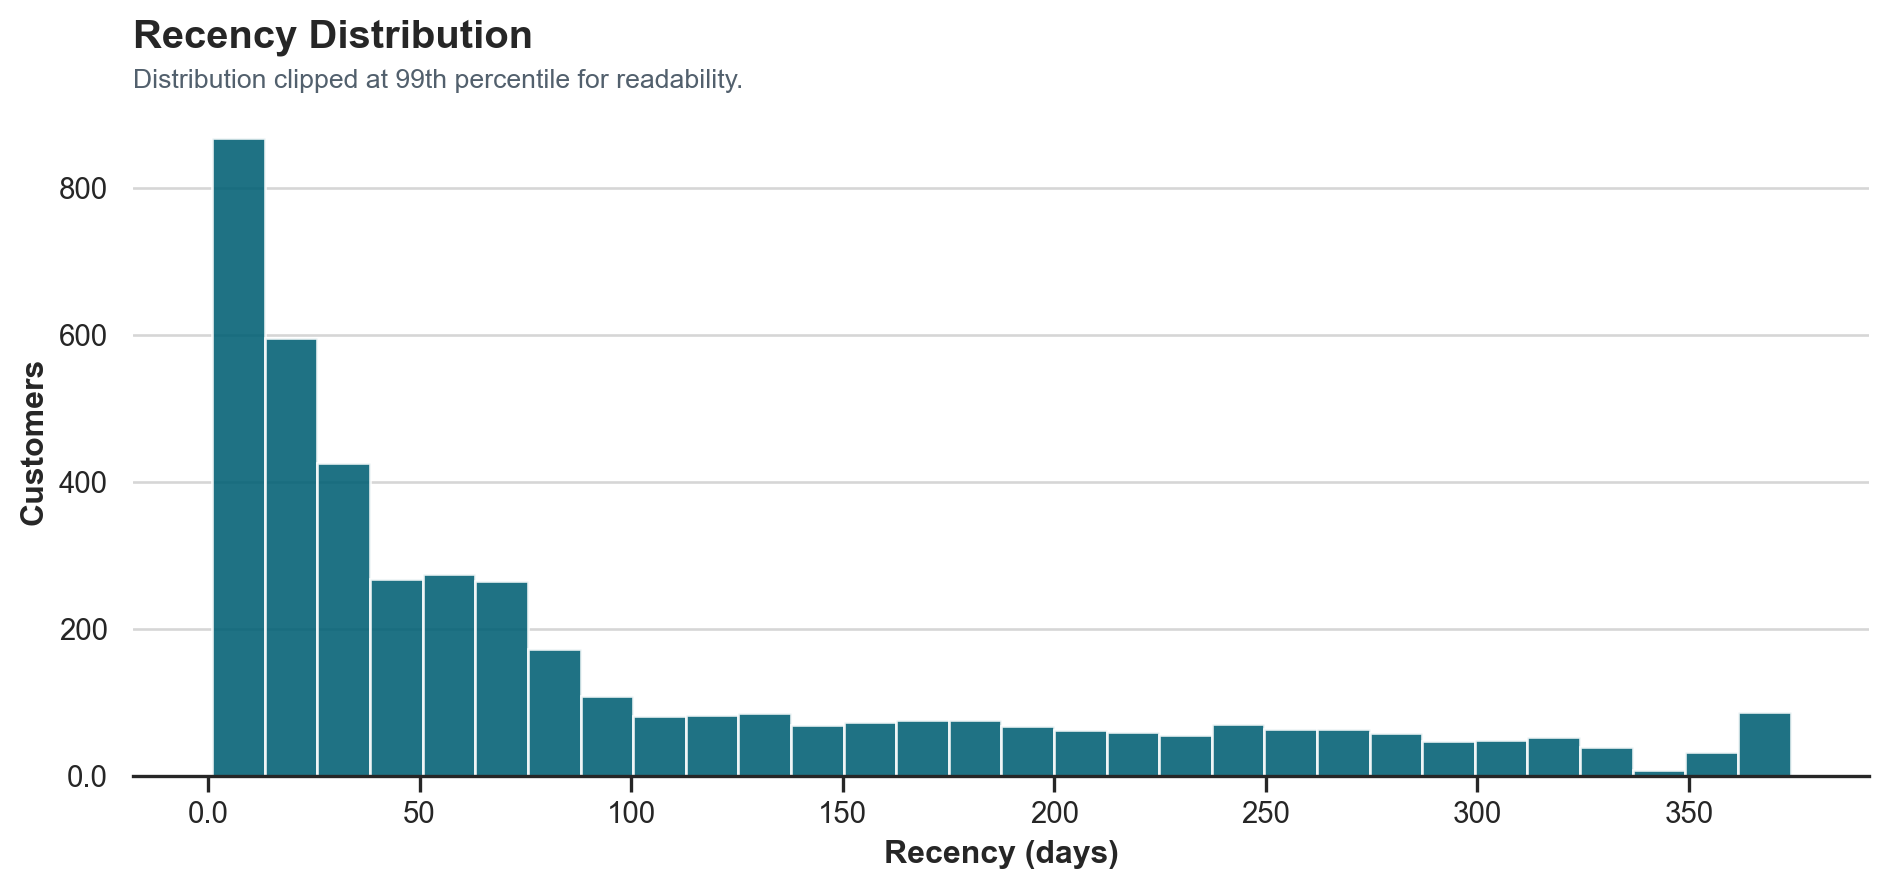

In [8]:
hist(
    rfm["Recency"],
    "Recency Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Recency (days)",
    PALETTE[0],
)


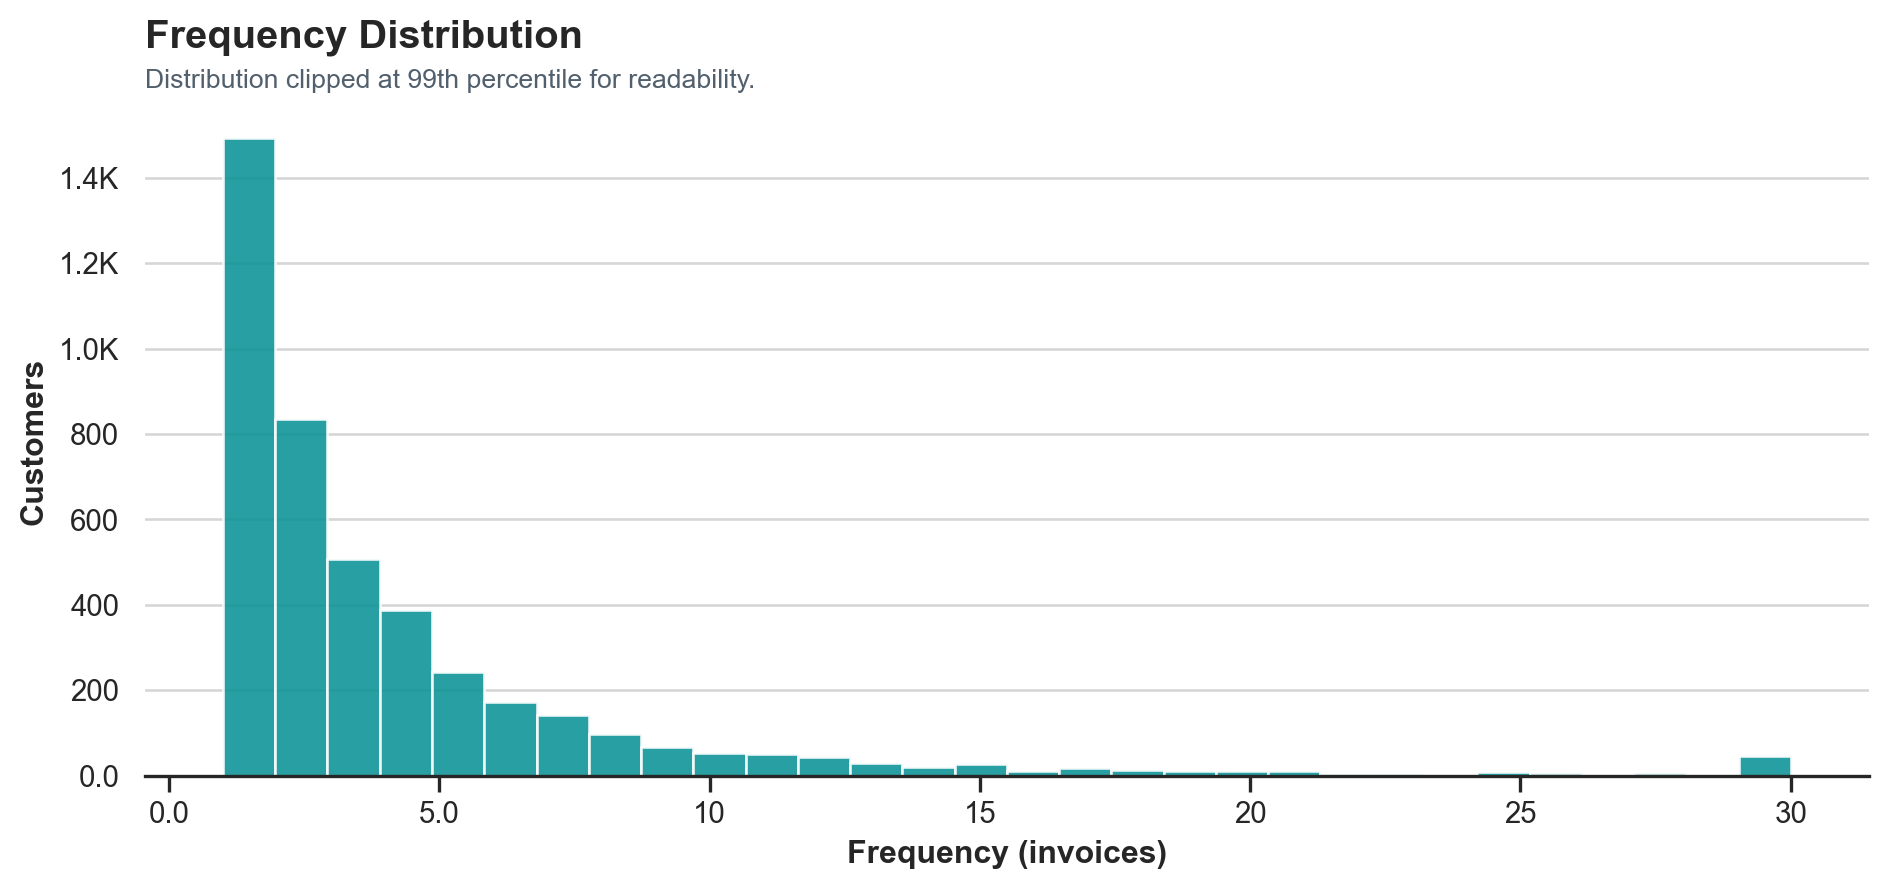

In [9]:
hist(
    rfm["Frequency"],
    "Frequency Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Frequency (invoices)",
    PALETTE[1],
    q=0.99,
)

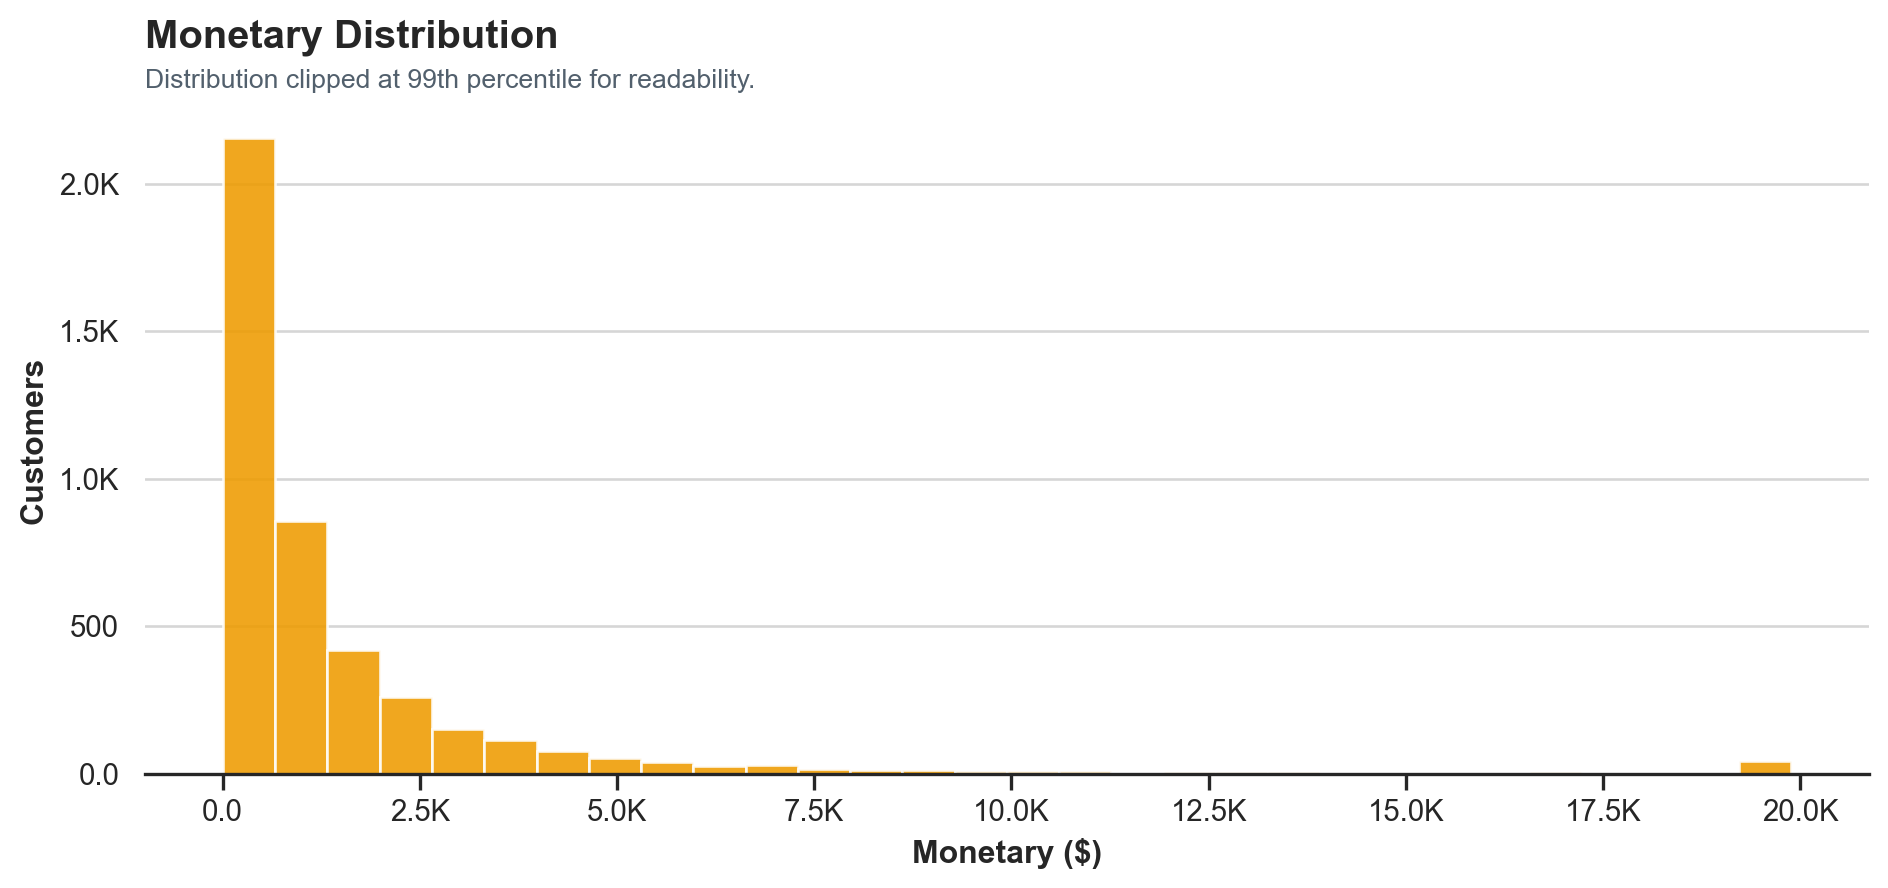

In [10]:
hist(
    rfm["Monetary"],
    "Monetary Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Monetary ($)",
    PALETTE[3],
    q=0.99,
)

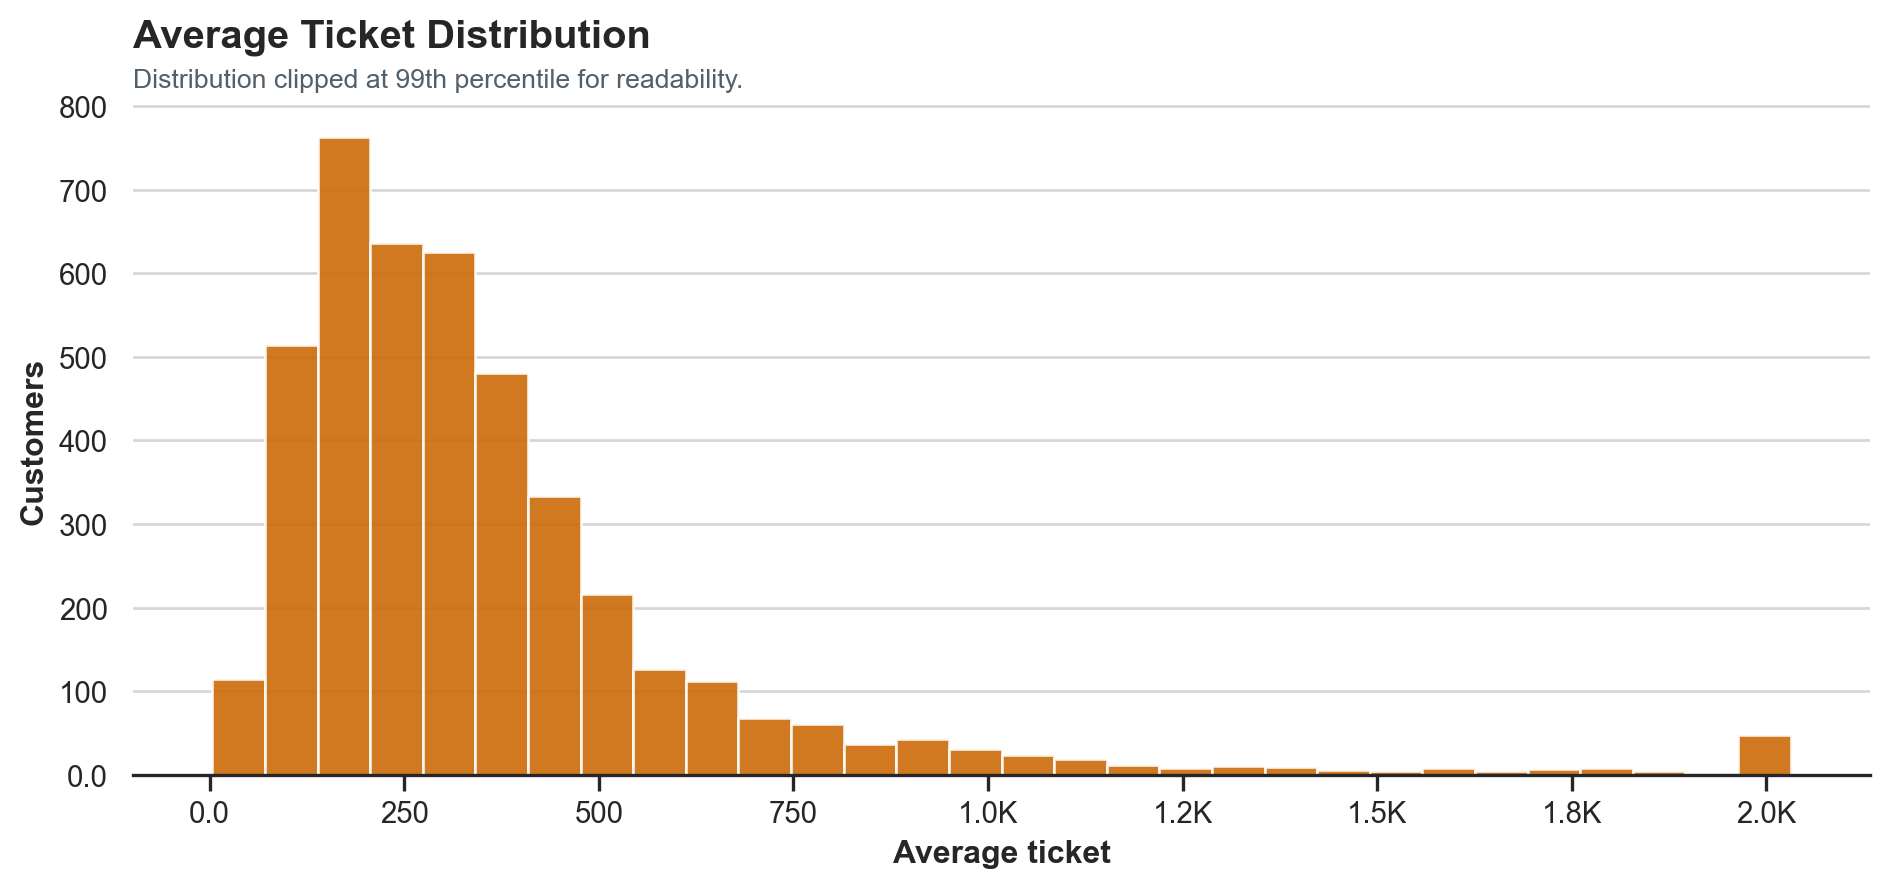

In [11]:
hist(
    rfm["AverageTicket"],
    "Average Ticket Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Average ticket",
    PALETTE[4],
    q=0.99,
)

**Insight (RFM distributions):** Recency is concentrated at low values with a long right tail, indicating many recent buyers and a dormant tail.
Frequency and Monetary are heavily right-skewed, with a small minority driving a disproportionate share of activity and revenue.
AverageTicket follows the same pattern, showing a premium tail that lifts averages above medians.
This supports a segmented strategy: broad low/mid-value base plus targeted treatment for high-value outliers.


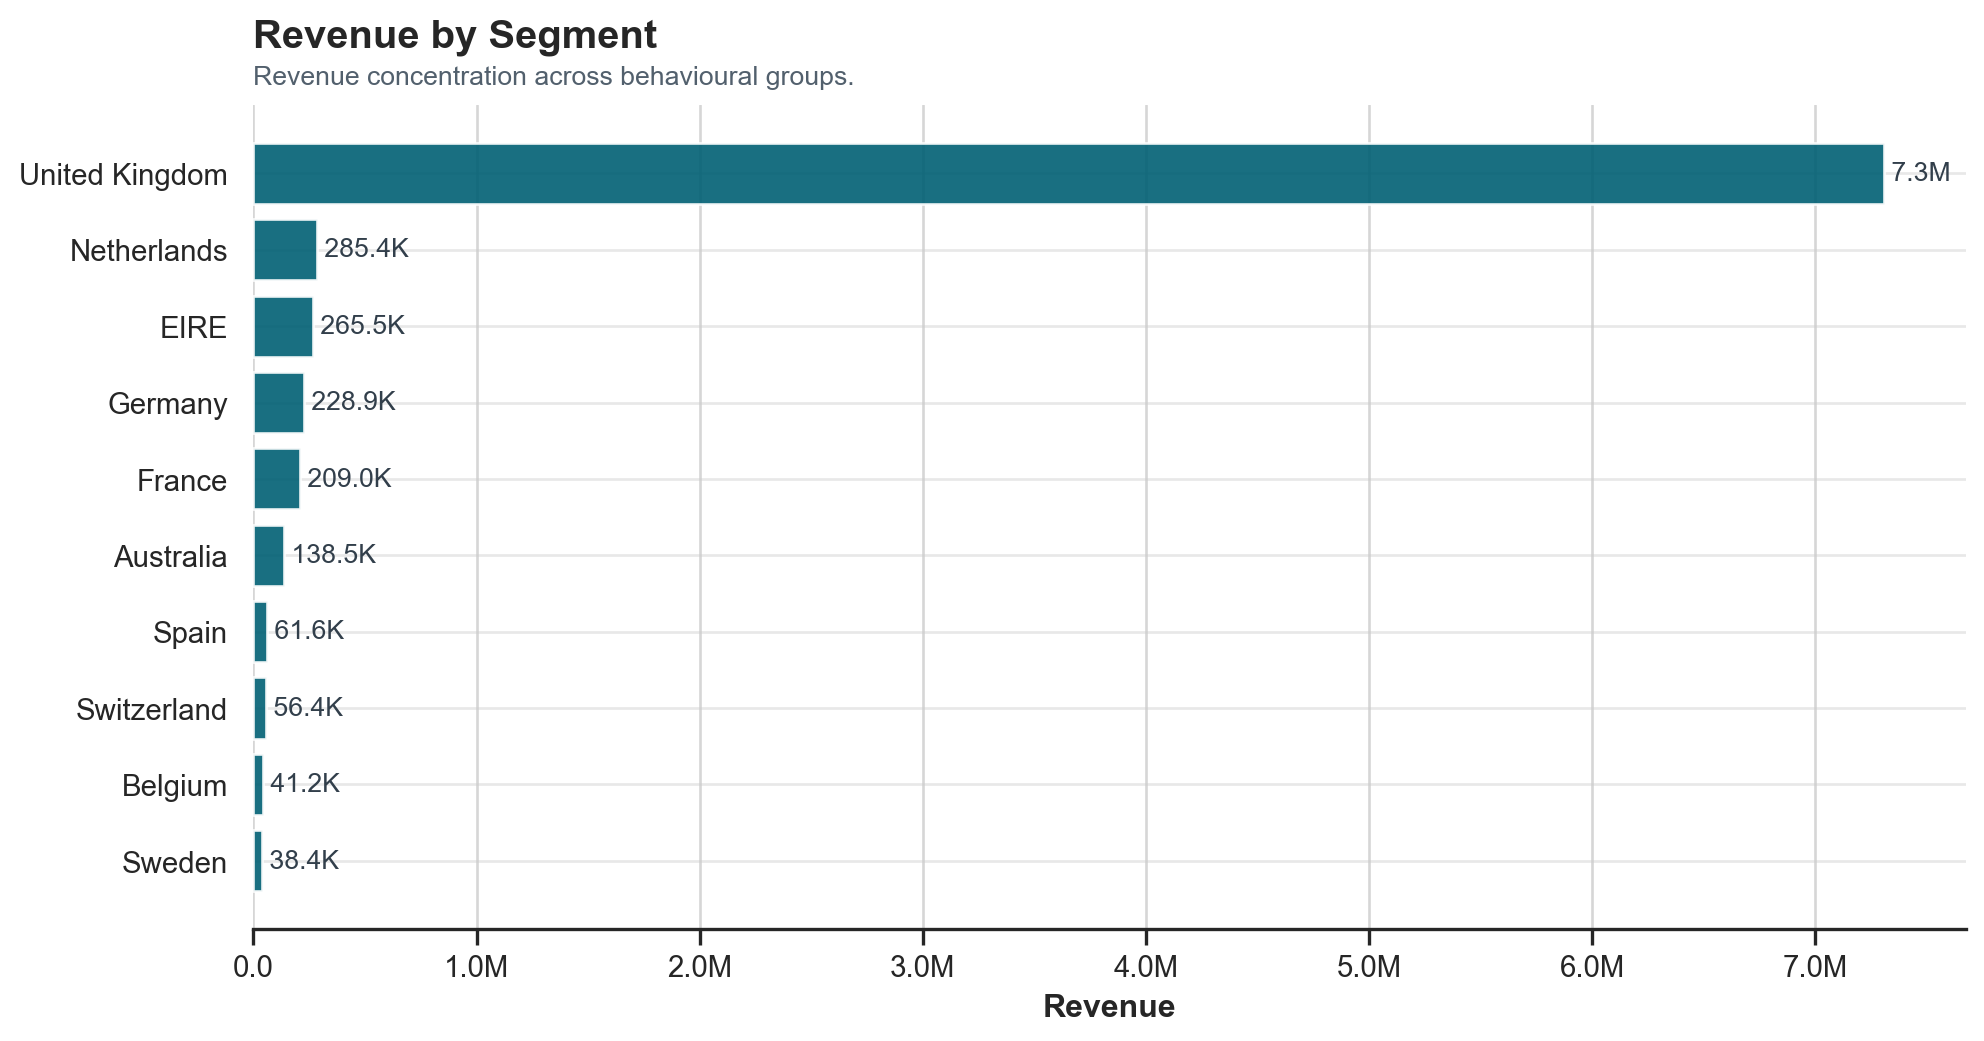

In [12]:
country_revenue = (
    clean_df.groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
    .head(10)
)
top_customers = rfm.nlargest(10, "Monetary")[["Customer ID", "Monetary"]]
barh(
    country_revenue.sort_values("Revenue"),
    "Country",
    "Revenue",
    "Revenue by Country",
    "Revenue concentration across top countries.",
    PALETTE[0],
)


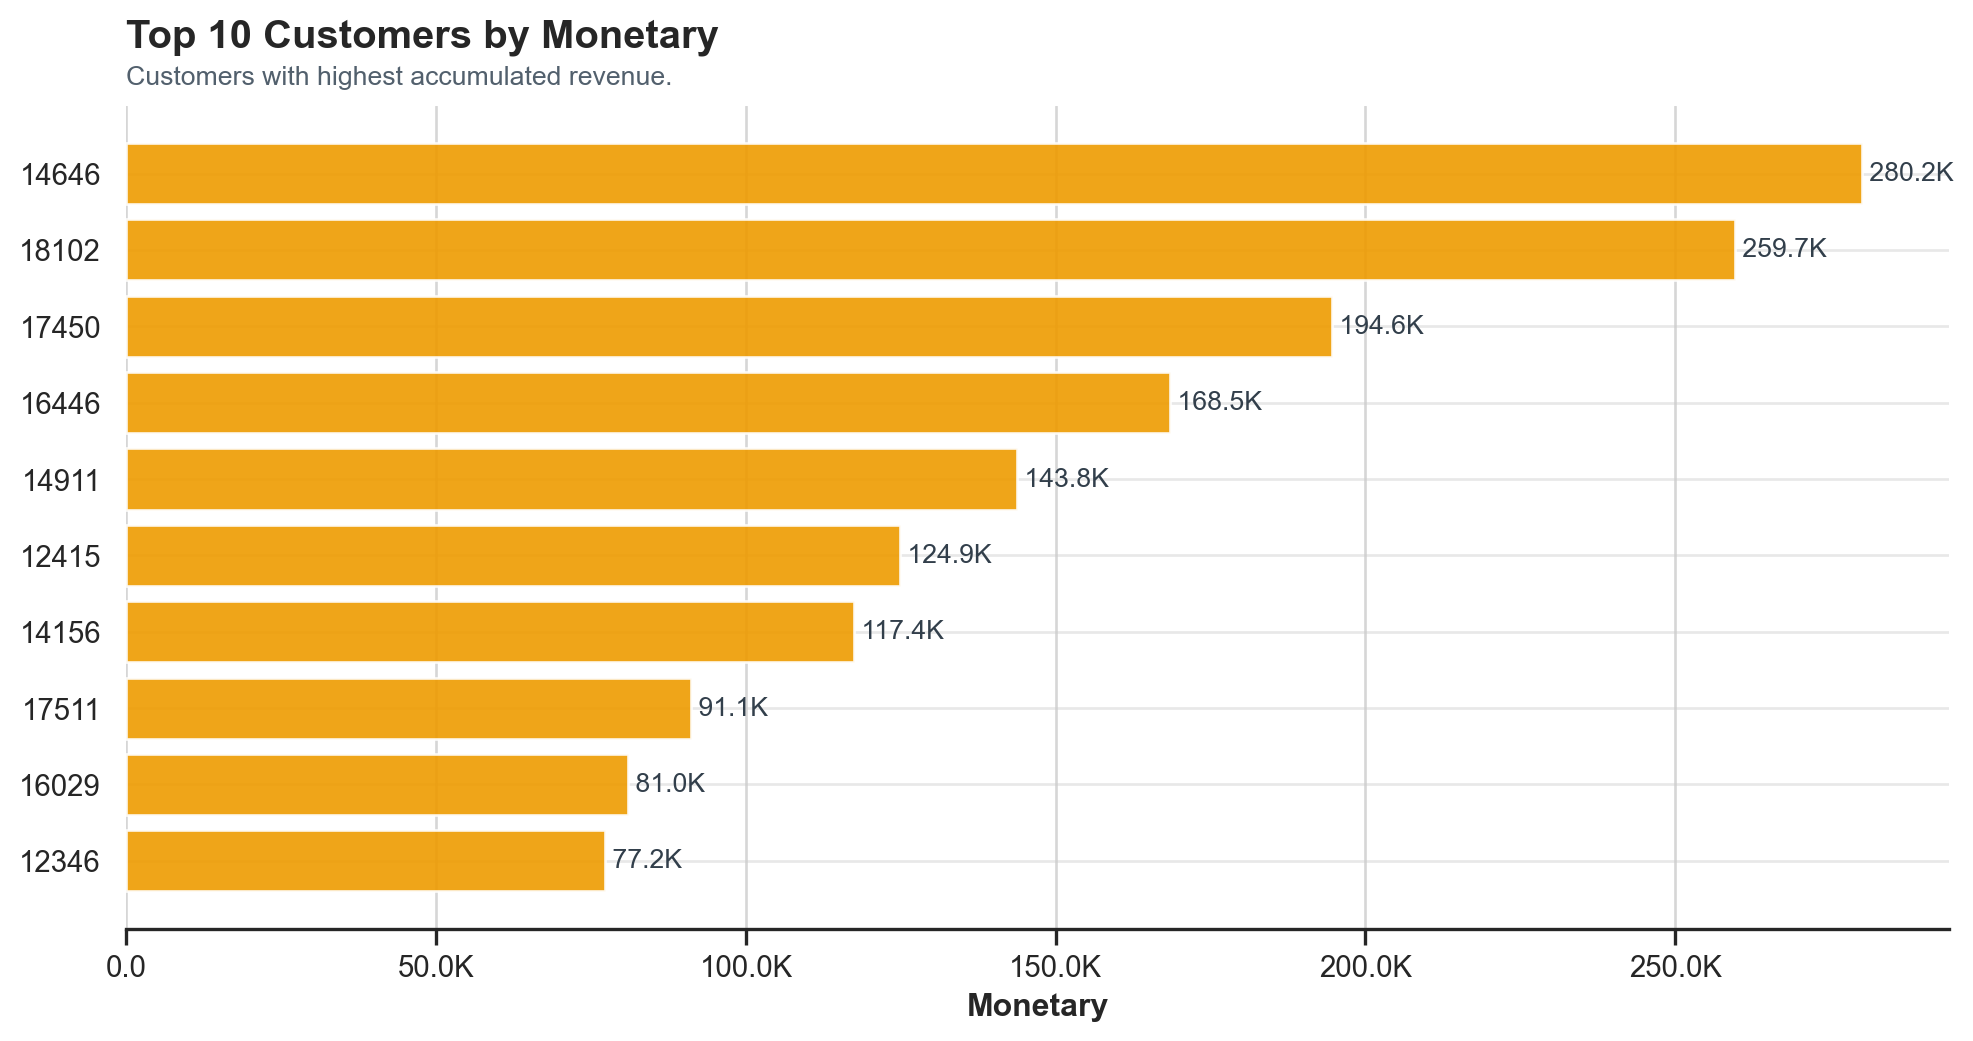

,Country,Revenue
35,United Kingdom,7308391.55
23,Netherlands,285446.34
10,EIRE,265545.90
14,Germany,228867.14
13,France,209024.05
0,Australia,138521.31
30,Spain,61577.11
32,Switzerland,56443.95
3,Belgium,41196.34
31,Sweden,38378.33


,Customer ID,Monetary
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194550.79
3008,16446,168472.50
1879,14911,143825.06
55,12415,124914.53
1333,14156,117379.63
3771,17511,91062.38
2702,16029,81024.84
0,12346,77183.60


In [13]:
barh(
    top_customers.sort_values("Monetary"),
    "Customer ID",
    "Monetary",
    "Top 10 Customers by Monetary",
    "Customers with highest accumulated revenue.",
    PALETTE[3],
)
display(country_revenue)
display(top_customers)

**Insight (country and concentration):** Revenue is concentrated in a limited set of countries, so geographic prioritization can improve campaign efficiency.
The top-customer table confirms power-law concentration at the customer level, with a few accounts carrying large monetary volume.
This concentration increases retention upside for top accounts but also creates dependency risk.
The result justifies combining segment-level strategy with account-level prioritization.


<span style="color:steelblue; text-align: left">

## 7. Customer Segmentation (K-Means)
</span>

The main variables are `Recency`, `Frequency`, `Monetary`, `AverageTicket` and `UniqueProducts`. The `log1p` transformation is applied to skewed variables to reduce the weight of outliers [Kuhn and Johnson, 2013; Hastie, Tibshirani and Friedman, 2009]. The features are then standardized because K-Means uses Euclidean distance and is sensitive to scale [MacQueen, 1967; Jain, 2010].

The final model is trained with the chosen number of clusters. K-Means seeks to partition observations into groups close to centroids, minimizing internal distances [MacQueen, 1967; Lloyd, 1982].


In [14]:
cluster_df = rfm[features].copy()
for col in log_features:
    cluster_df[col] = np.log1p(cluster_df[col])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(cluster_df)

print("Standardization used: StandardScaler")
display(cluster_df.head())

Standardization used: StandardScaler


,Recency,Frequency,Monetary,AverageTicket,UniqueProducts
0,326,0.69,11.25,11.25,0.69
1,2,2.08,8.37,6.42,4.64
2,75,1.61,7.49,6.11,3.14
3,19,0.69,7.47,7.47,4.30
4,310,0.69,5.82,5.82,2.89


In [15]:
from src.segmentation import fit_kmeans

labels, final_inertia = fit_kmeans(x_scaled, selected_k, n_init=20)
rfm["Cluster"] = labels.astype(int)

cluster_vars = [
    "Recency", "Frequency", "Monetary",
    "AverageTicket", "QuantityTotal", "UniqueProducts",
]
cluster_size = (
    rfm["Cluster"].value_counts().sort_index()
    .rename_axis("Cluster").reset_index(name=t("Customers (n)"))
)
cluster_mean   = rfm.groupby("Cluster")[cluster_vars].mean().round(2)
cluster_median = rfm.groupby("Cluster")[cluster_vars].median().round(2)
cluster_revenue = rfm.groupby("Cluster", as_index=False).agg(
    TotalRevenue=("Monetary", "sum")
)
cluster_revenue["RevenuePercentage"] = (
    cluster_revenue["TotalRevenue"] / cluster_revenue["TotalRevenue"].sum() * 100
).round(2)

display(cluster_size)
display(cluster_mean)
display(cluster_median)
display(cluster_revenue)

,Cluster,Customers (n)
0,0,1142
1,1,449
2,2,670
3,3,448
4,4,1089
5,5,540


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,55.91,1.86,434.58,255.38,276.84,28.52
1,16.16,17.41,11245.44,612.25,6324.33,196.29
2,271.27,1.35,372.05,295.37,202.65,21.94
3,137.26,1.49,135.76,97.84,107.60,7.61
4,36.36,5.37,1575.88,308.07,969.93,86.85
5,87.92,2.18,2480.89,1249.23,1429.28,61.84


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,46.00,2.00,389.96,235.38,227.50,24.00
1,9.00,13.00,5346.23,450.99,3065.00,158.00
2,267.50,1.00,312.94,263.24,152.00,18.00
3,128.50,1.00,118.78,96.21,66.00,6.00
4,24.00,5.00,1421.29,298.97,829.00,75.00
5,71.00,2.00,1340.98,706.78,757.00,50.00


,Cluster,TotalRevenue,RevenuePercentage
0,0,496295.36,5.57
1,1,5049204.49,56.66
2,2,249271.17,2.80
3,3,60821.47,0.68
4,4,1716135.50,19.26
5,5,1339679.91,15.03


**Insight (cluster tables):** Differences between means and medians indicate asymmetric distributions inside clusters, especially for Monetary and Frequency.
Revenue share by cluster shows that customer volume and economic value are not equivalent dimensions.
Some clusters can be large but low-value, while smaller clusters can dominate contribution.
This is why segment naming and prioritization should be anchored in economic impact, not only size.


<span style="color:steelblue; text-align: left">

## 8. Cluster Validation (Elbow + Silhouette)
</span>

Values of `k` between 2 and 10 are tested. The analysis uses `inertia`, related to the internal compactness typical of the K-Means least squares objective [Lloyd, 1982; Jain, 2010], and `silhouette_score`, to evaluate cohesion and separation between clusters [Rousseeuw, 1987]. The final choice combines metric and business utility, since a mathematically good number may be too broad to guide actions [Wedel and Kamakura, 2000].


,k,inertia,silhouette_score
0,2,13156.48,0.33
1,3,10491.56,0.27
2,4,8863.36,0.27
3,5,7823.97,0.25
4,6,6993.07,0.25
5,7,6465.53,0.24
6,8,6002.72,0.22
7,9,5638.86,0.22
8,10,5329.29,0.22


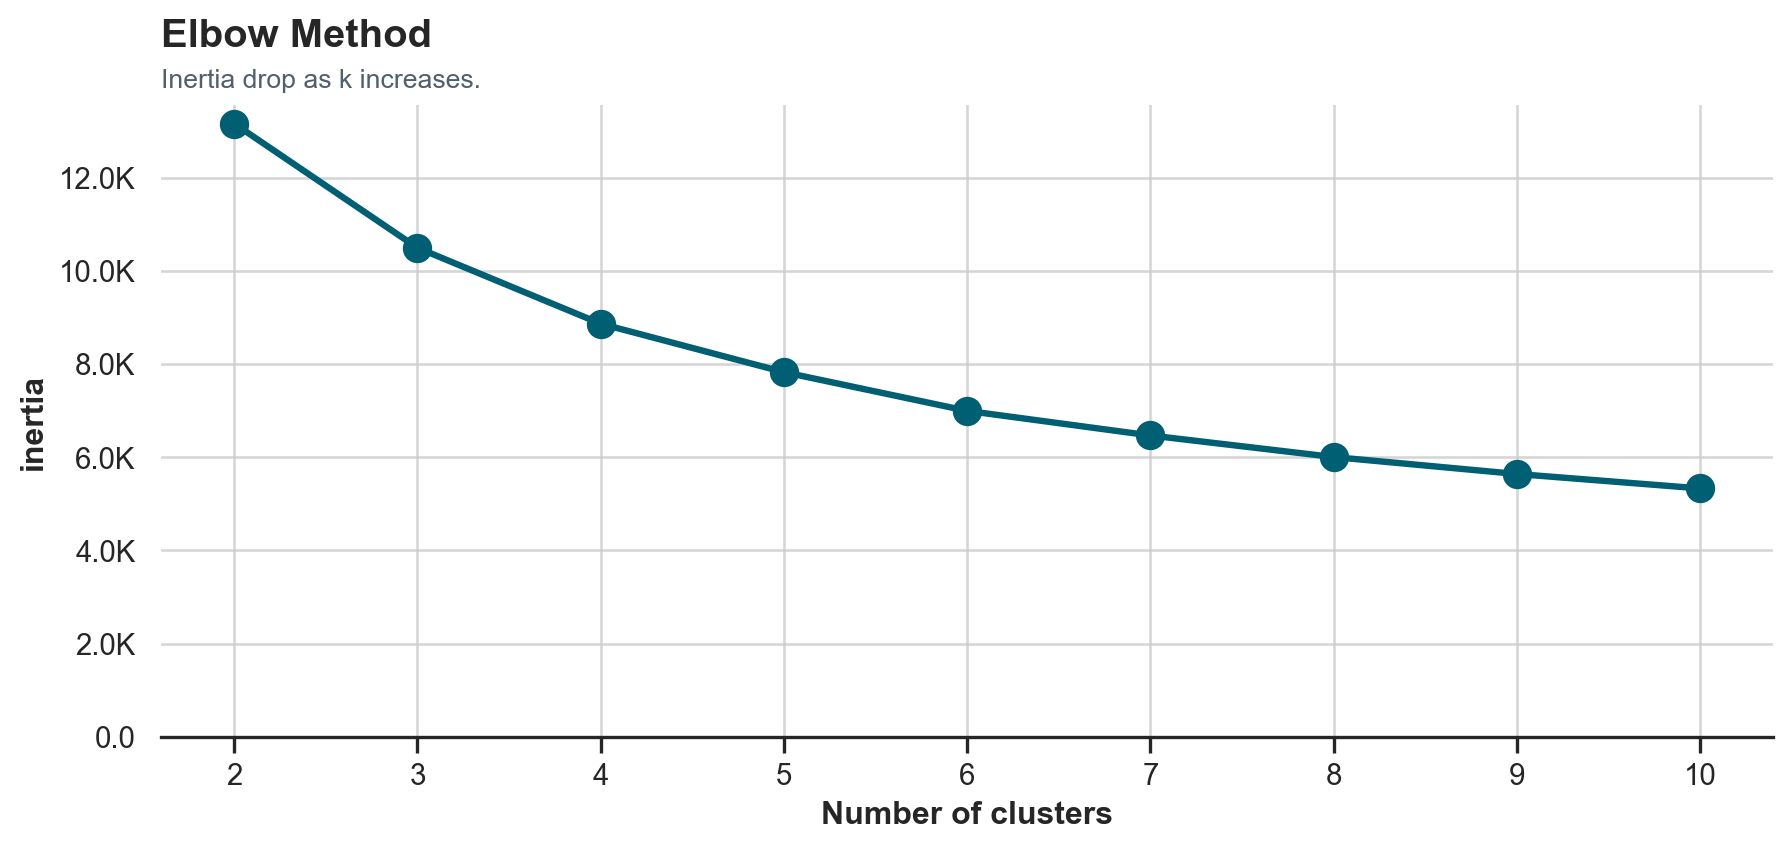

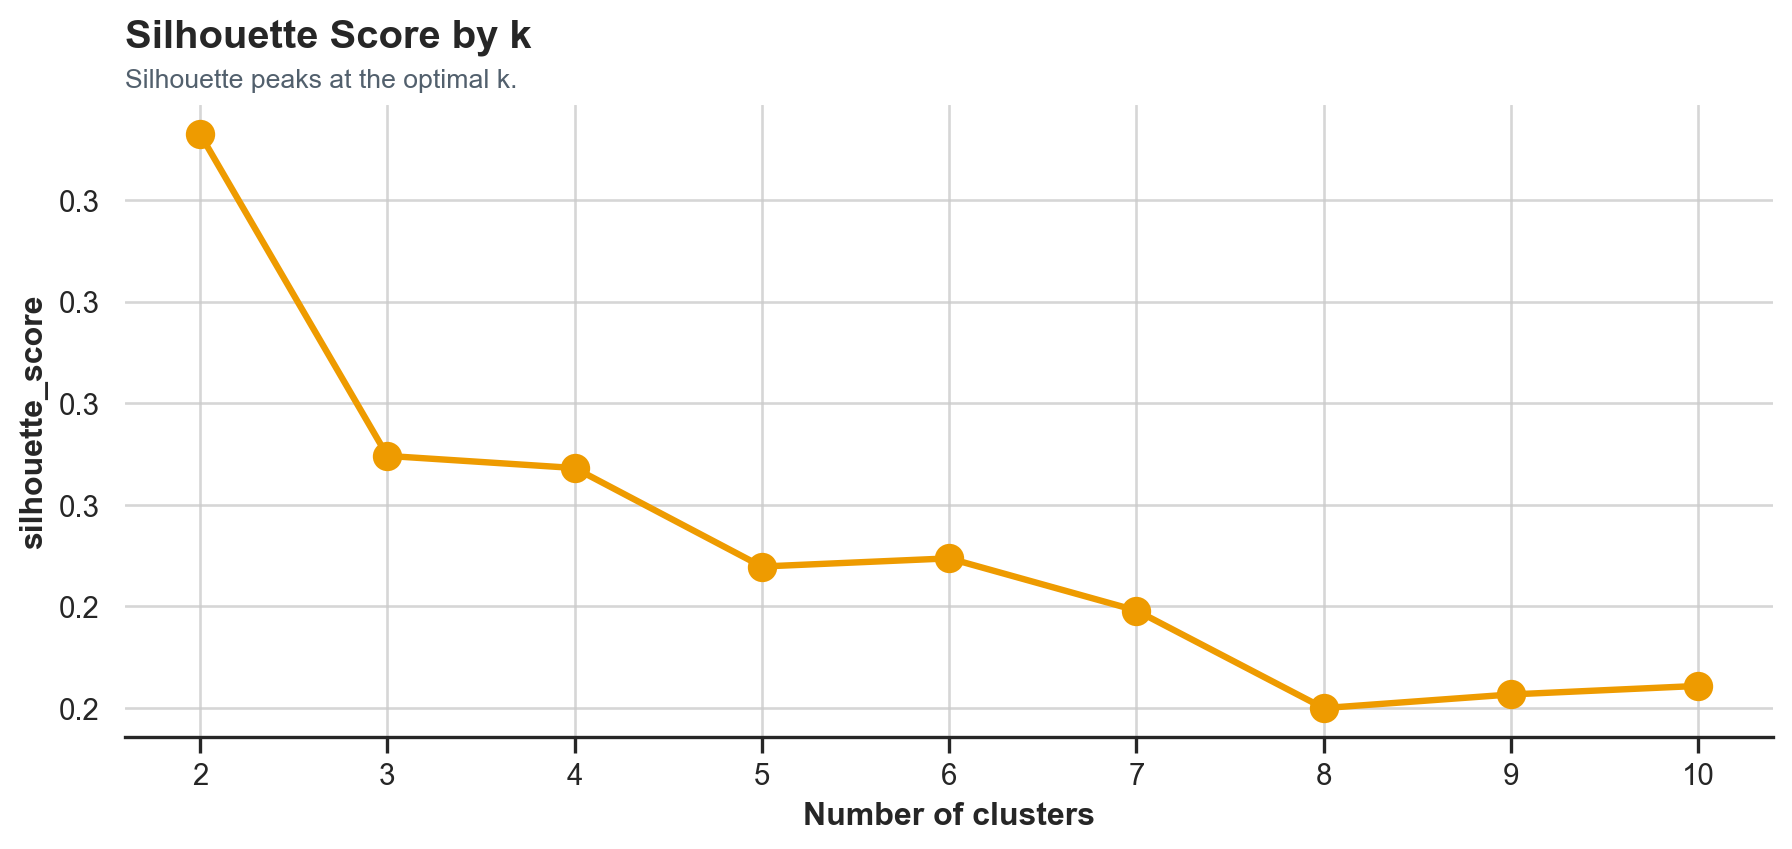

**Number of clusters chosen: 6.**

The highest silhouette was observed at `k=2`. `k=6` was chosen because it offers more actionable segments for Next Best Action, separating high-value customers, loyal customers, occasional buyers, low-value customers, inactive customers and at-risk high-value customers. The decision prioritizes a balance between statistical quality, interpretability and business utility.

In [16]:
k_metrics = search_k(x_scaled, k_range=range(2, 11))
display(k_metrics.round(4))

lineplot(k_metrics, "k", "inertia", "Elbow Method",
         "Inertia drop as k increases.", PALETTE[0], zero=True)
lineplot(k_metrics, "k", "silhouette_score", "Silhouette Score by k",
         "Silhouette peaks at the optimal k.", PALETTE[3])

best_k = int(k_metrics.loc[k_metrics["silhouette_score"].idxmax(), "k"])
text = (
    f"**Number of clusters chosen: {selected_k}.**\n\n"
    f"The highest silhouette was observed at `k={best_k}`. "
    f"`k={selected_k}` was chosen because it offers more actionable segments "
    "for Next Best Action, separating high-value customers, loyal customers, "
    "occasional buyers, low-value customers, inactive customers and at-risk "
    "high-value customers. The decision prioritizes a balance between statistical "
    "quality, interpretability and business utility."
)
display(Markdown(text))

**Insight (k selection):** The elbow curve shows diminishing inertia gains after the mid-range of k, while silhouette peaks around k=6.
A silhouette score of 0.38 indicates moderate separation; values below 0.5 usually imply overlap between groups.
That overlap is expected in behavioral RFM data, where boundaries are gradual rather than rigid.
k=6 was kept deliberately because it balances interpretability and actionable business granularity.


<span style="color:steelblue; text-align: left">

## 9. Segment Profiling and Naming
</span>

The cluster number has no business meaning. The interpretation below transforms each group into a segment using recency, frequency, revenue, average ticket and product variety. This translation of statistical groupings into managerial segments is central to applied market segmentation [Wedel and Kamakura, 2000; Chen, Sain and Guo, 2012].

The visualizations connect patterns of frequency, value, recency, revenue and segment size. Exploratory charts help validate whether the groups are interpretable and whether the solution makes sense beyond the numerical metric [Tukey, 1977; Rousseeuw, 1987]. Readings should consider that lower `Recency` represents a more recent purchase.


In [17]:
ACTIONS = {
    "Champions":          "Offer VIP program, early access and exclusive benefits.",
    "High Value at Risk": "Prioritize reactivation campaigns and personalized offers.",
    "Loyal Customers":    "Encourage cross-sell and bundles.",
    "Occasional Buyers":  "Second-purchase campaigns and low-cost coupons.",
    "Low Value":          "Low-cost marketing automation.",
    "Inactive Customers": "Targeted reactivation or low priority.",
}

profile = rfm.groupby("Cluster").agg(
    Cluster=("Cluster", "first"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AverageTicket=("AverageTicket", "mean"),
    UniqueProducts=("UniqueProducts", "mean"),
    TotalRevenue=("Monetary", "sum"),
    Customers=("Customer ID", "count"),
).reset_index(drop=True)
profile["RevenuePercentage"] = (
    profile["TotalRevenue"] / profile["TotalRevenue"].sum() * 100
)

names = segment_names(profile)
validate_segment_names(profile, names)

profile["SegmentName"] = profile["Cluster"].map(names)
rfm["SegmentName"]    = rfm["Cluster"].map(names)
rfm["NextBestAction"] = rfm["SegmentName"].map(ACTIONS)

segment_table = profile.sort_values("TotalRevenue", ascending=False)
display(segment_table)

,Cluster,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,TotalRevenue,Customers,RevenuePercentage,SegmentName
1,1,16.16,17.41,11245.44,612.25,196.29,5049204.49,449,56.66,Champions
4,4,36.36,5.37,1575.88,308.07,86.85,1716135.50,1089,19.26,Loyal Customers
5,5,87.92,2.18,2480.89,1249.23,61.84,1339679.91,540,15.03,High Value at Risk
0,0,55.91,1.86,434.58,255.38,28.52,496295.36,1142,5.57,Occasional Buyers
2,2,271.27,1.35,372.05,295.37,21.94,249271.17,670,2.80,Inactive Customers
3,3,137.26,1.49,135.76,97.84,7.61,60821.47,448,0.68,Low Value


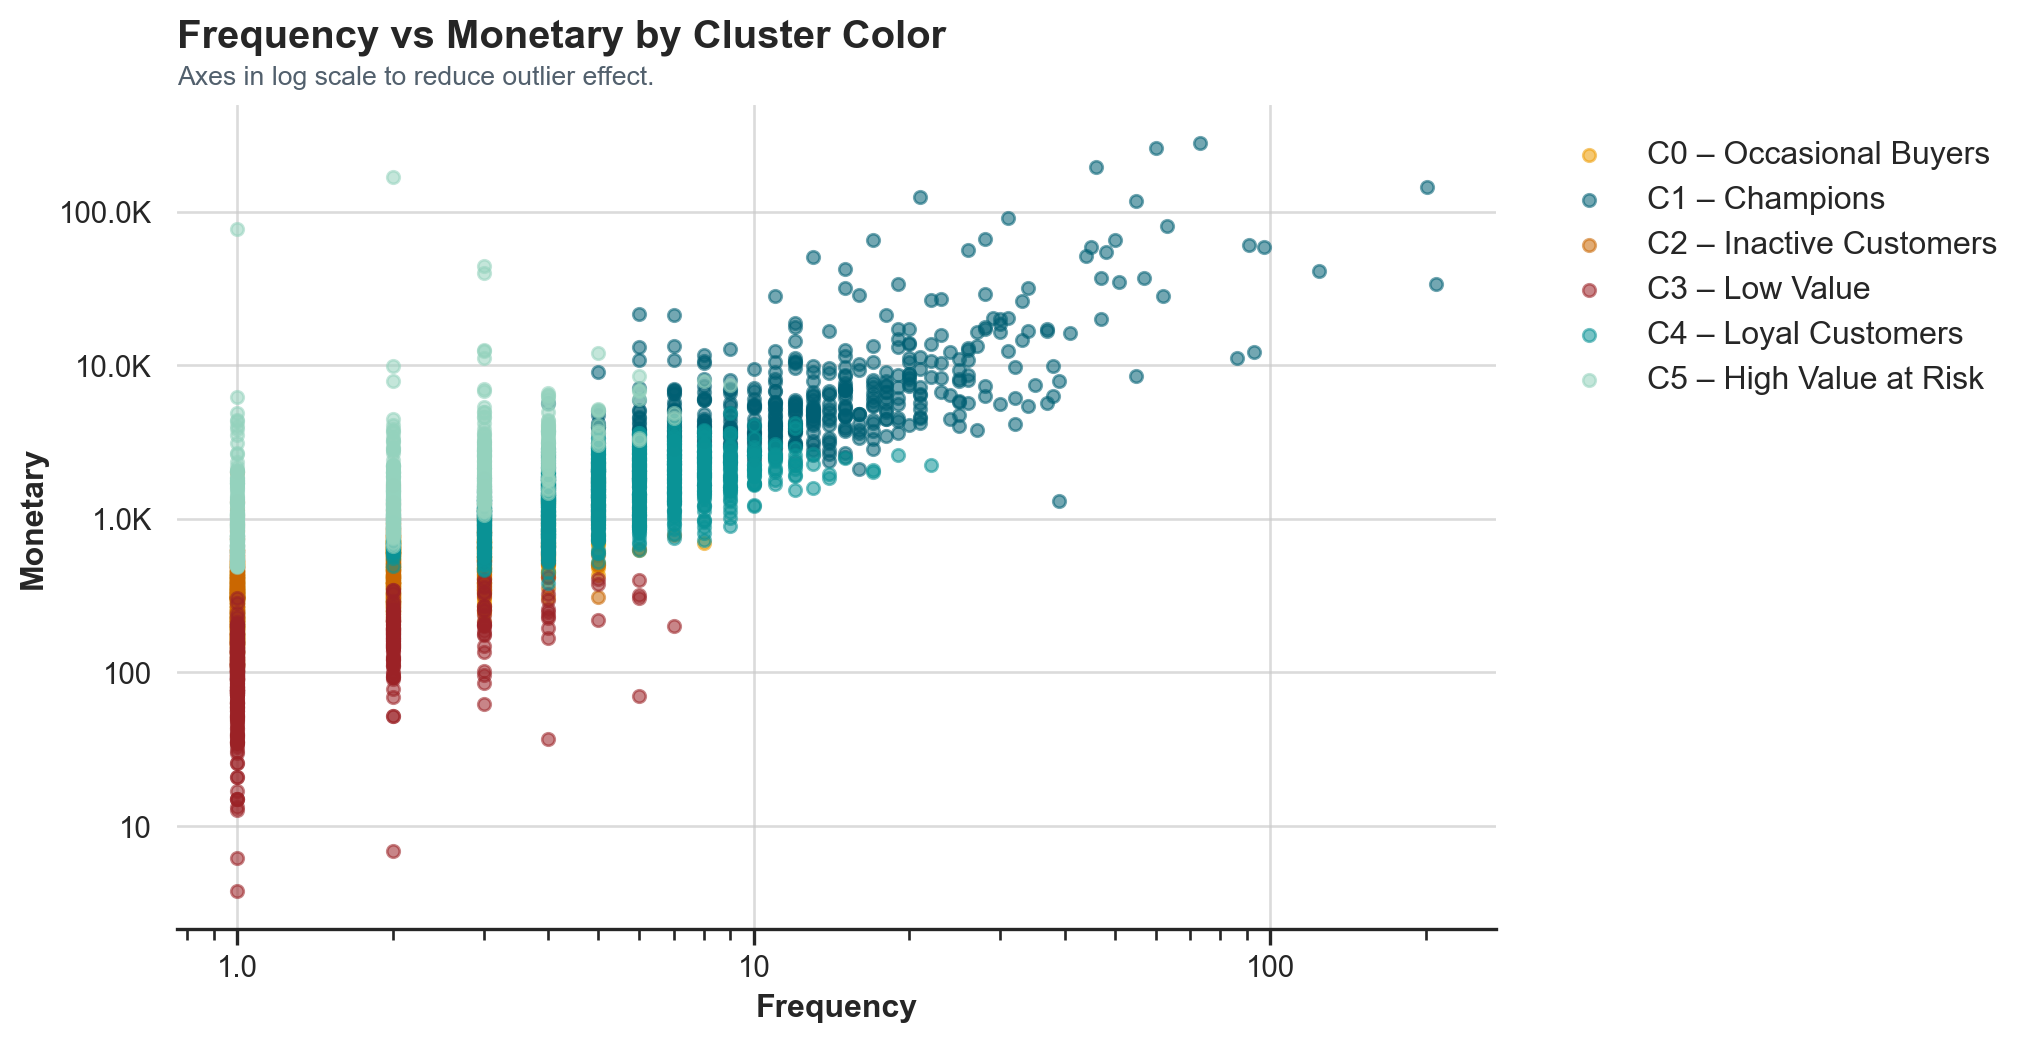

In [ ]:
order = segment_table["Cluster"].tolist()
cluster_colors = {cl: PALETTE[i % len(PALETTE)] for i, cl in enumerate(order)}

scatter(rfm, "Frequency", "Monetary",
        "Frequency vs Monetary by Cluster Color",
        "Axes in log scale to reduce outlier effect.",
        cluster_colors, logx=True, logy=True)

**Insight (Frequency vs Monetary):** On log-log scale, clusters separate primarily by spending level and purchase cadence, not by a single linear cutoff.
The upper-right region concentrates high-frequency, high-monetary customers, consistent with premium relationship segments.
Lower-frequency and lower-monetary clusters occupy the dense operational base and need lower-cost or reactivation tactics.
This visual is a key validation that segmentation captures economically distinct behaviors before prediction.


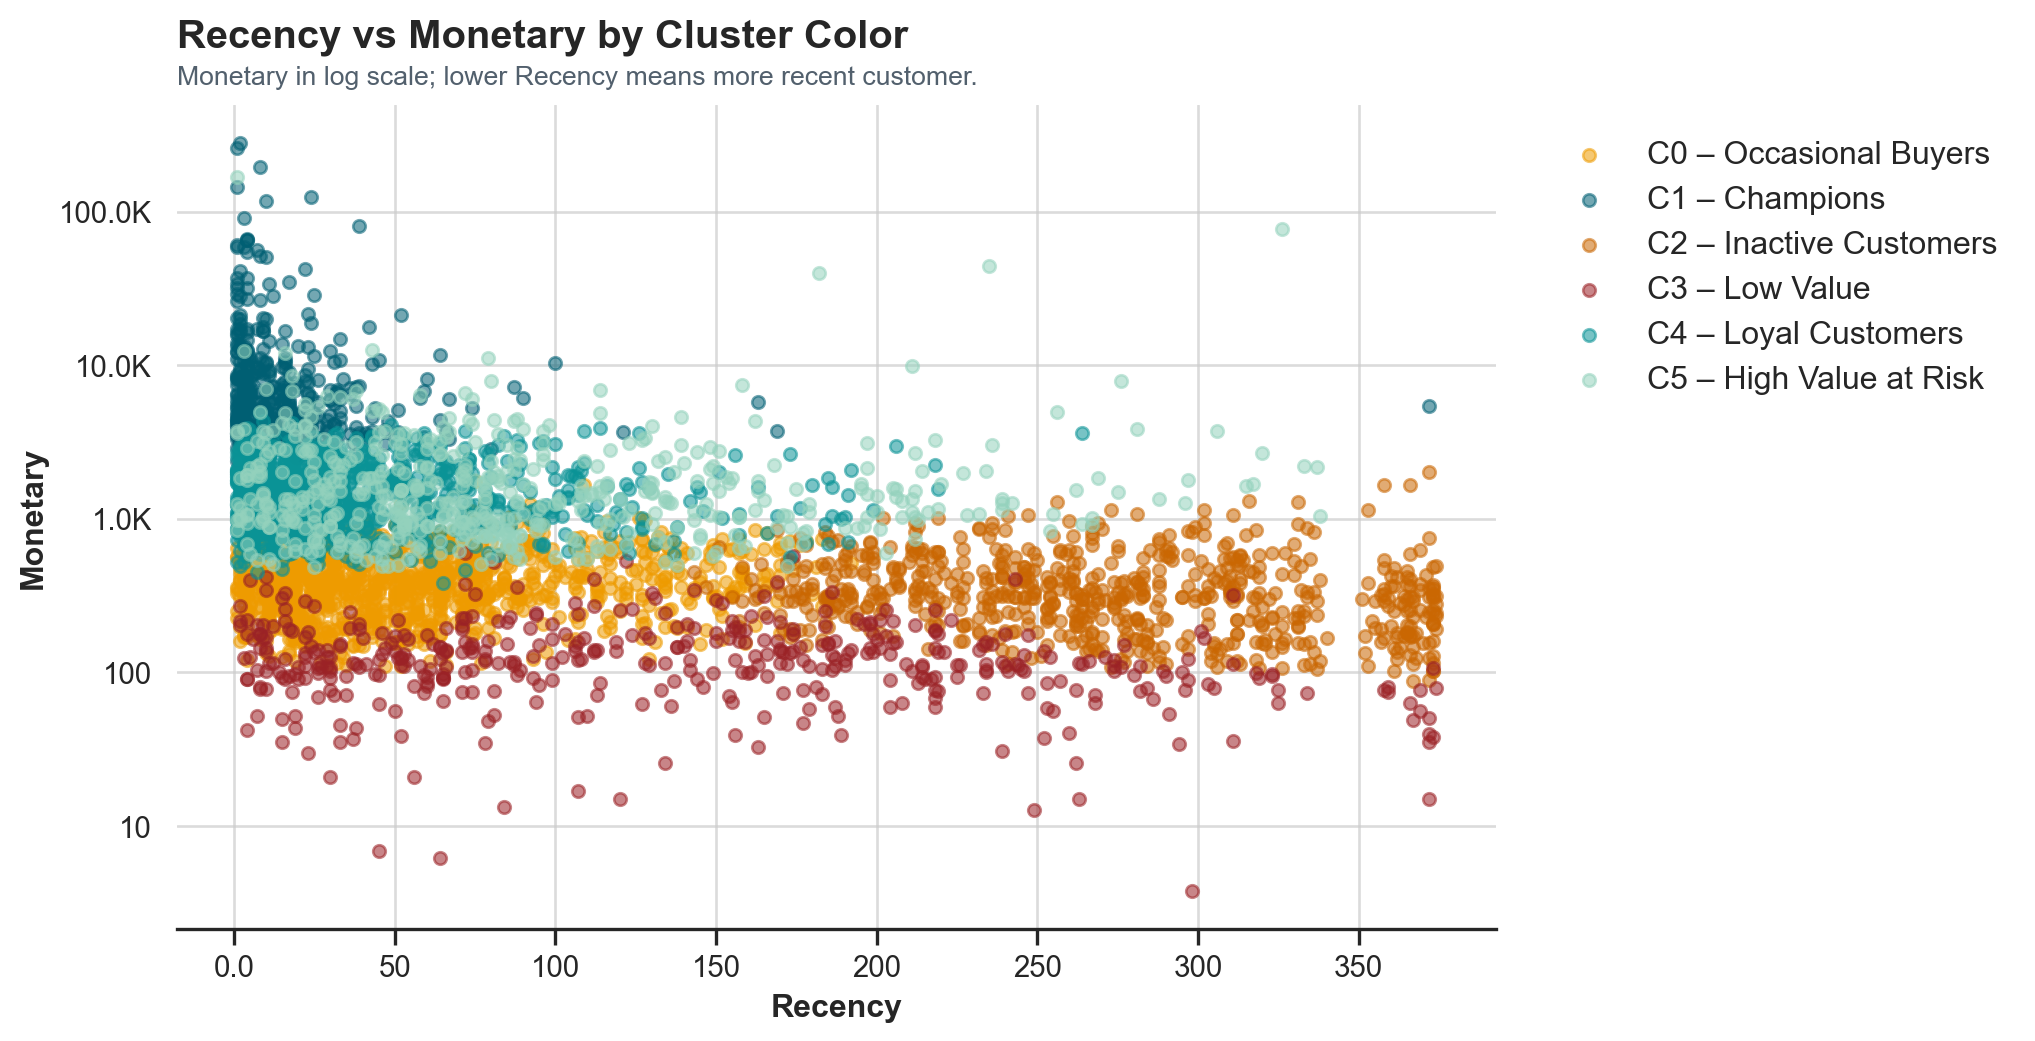

In [19]:
scatter(rfm, "Recency", "Monetary",
        "Recency vs Monetary by Cluster Color",
        "Monetary in log scale; lower Recency means more recent customer.",
        cluster_colors, logy=True)


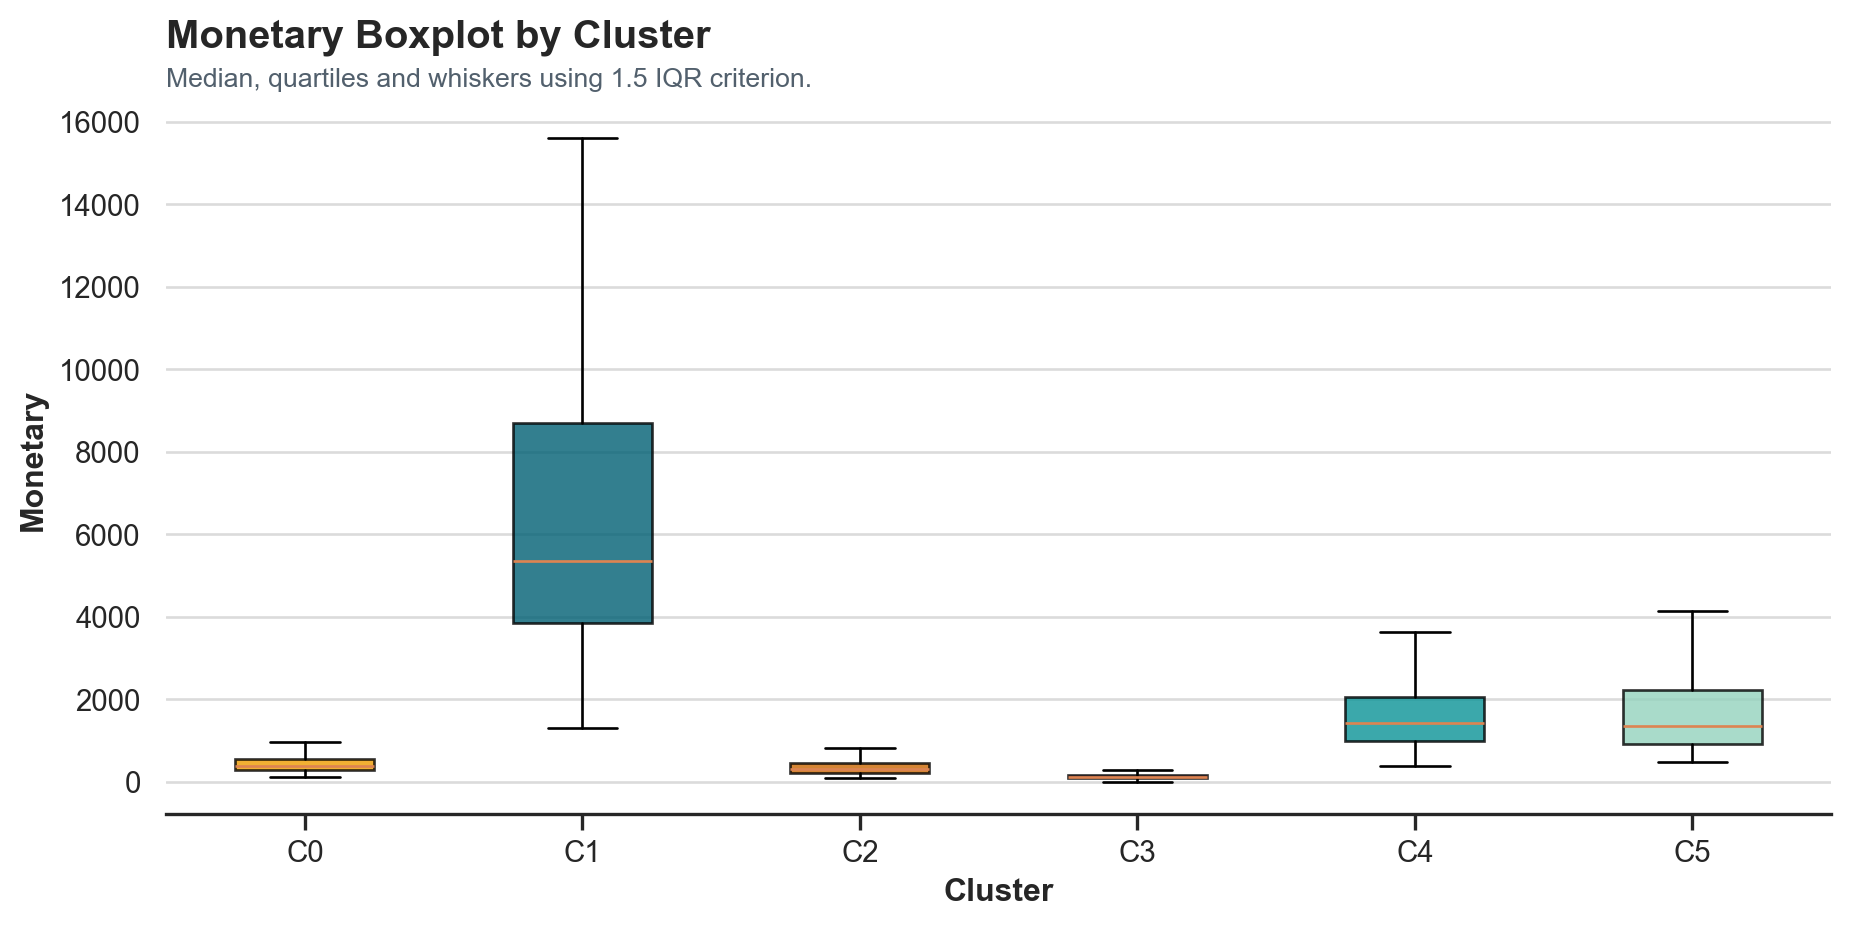

In [20]:
boxplot(rfm, "Cluster", "Monetary",
        "Monetary Boxplot by Cluster",
        "Median, quartiles and whiskers using 1.5 IQR criterion.",
        cluster_colors)

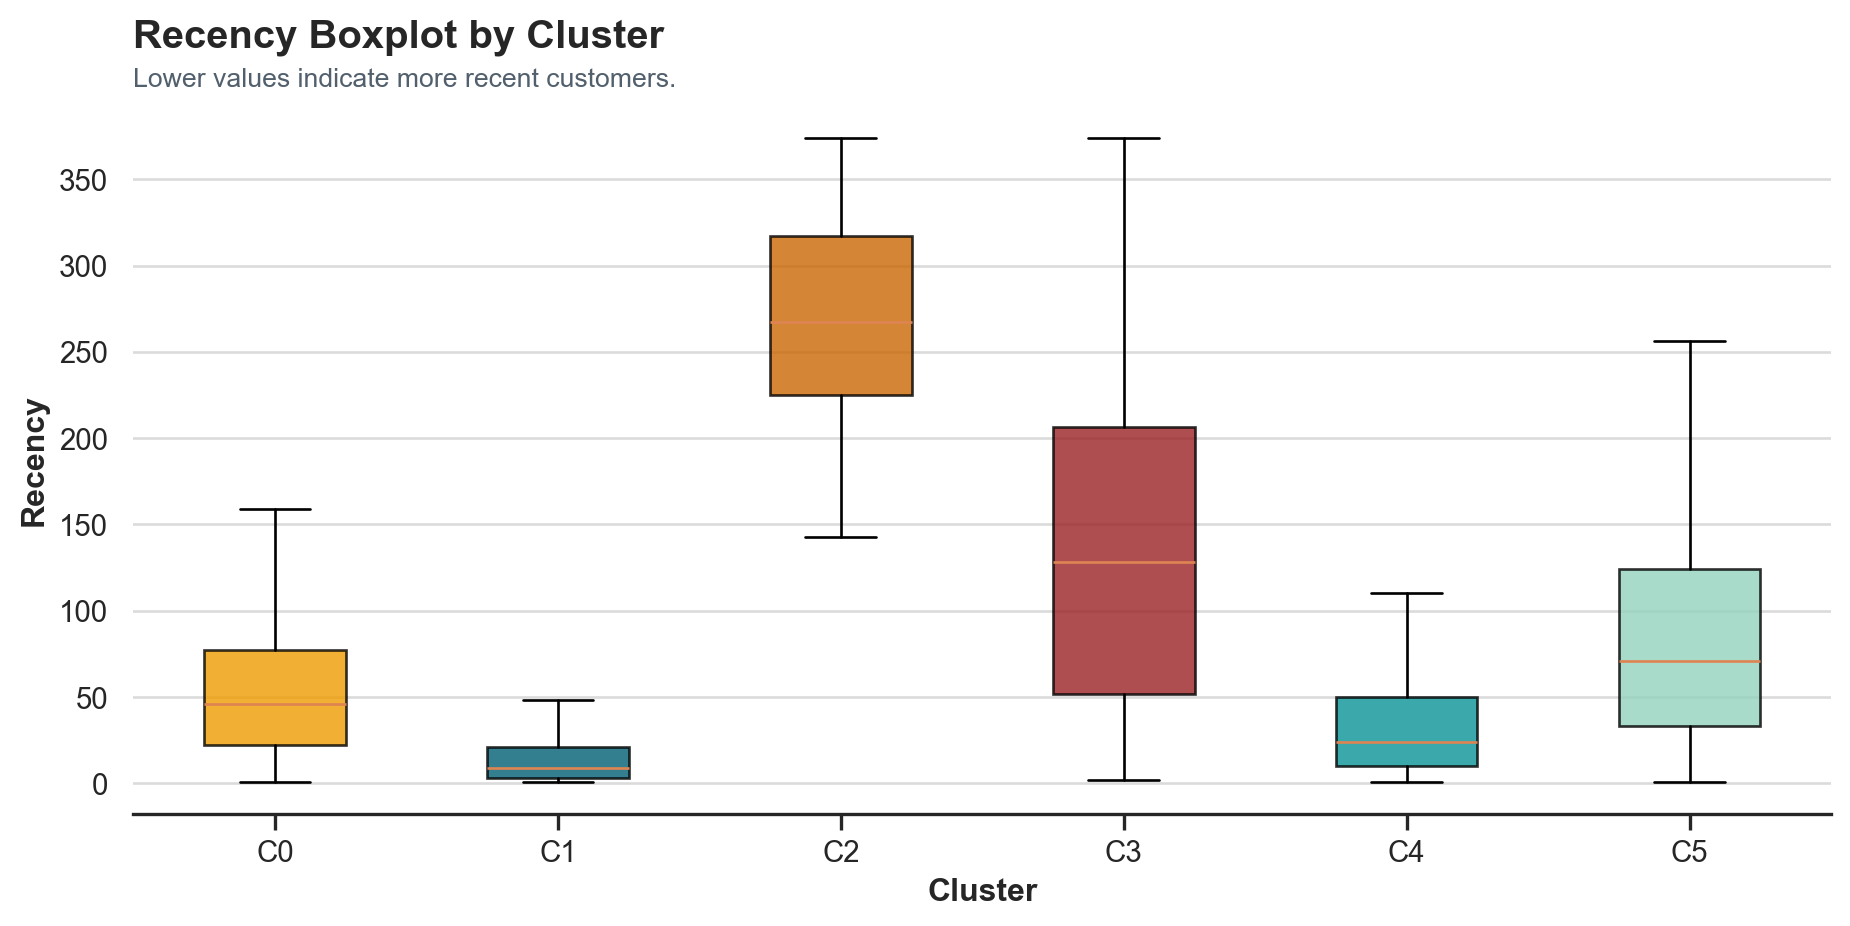

In [21]:
boxplot(rfm, "Cluster", "Recency",
        "Recency Boxplot by Cluster",
        "Lower values indicate more recent customers.",
        cluster_colors)


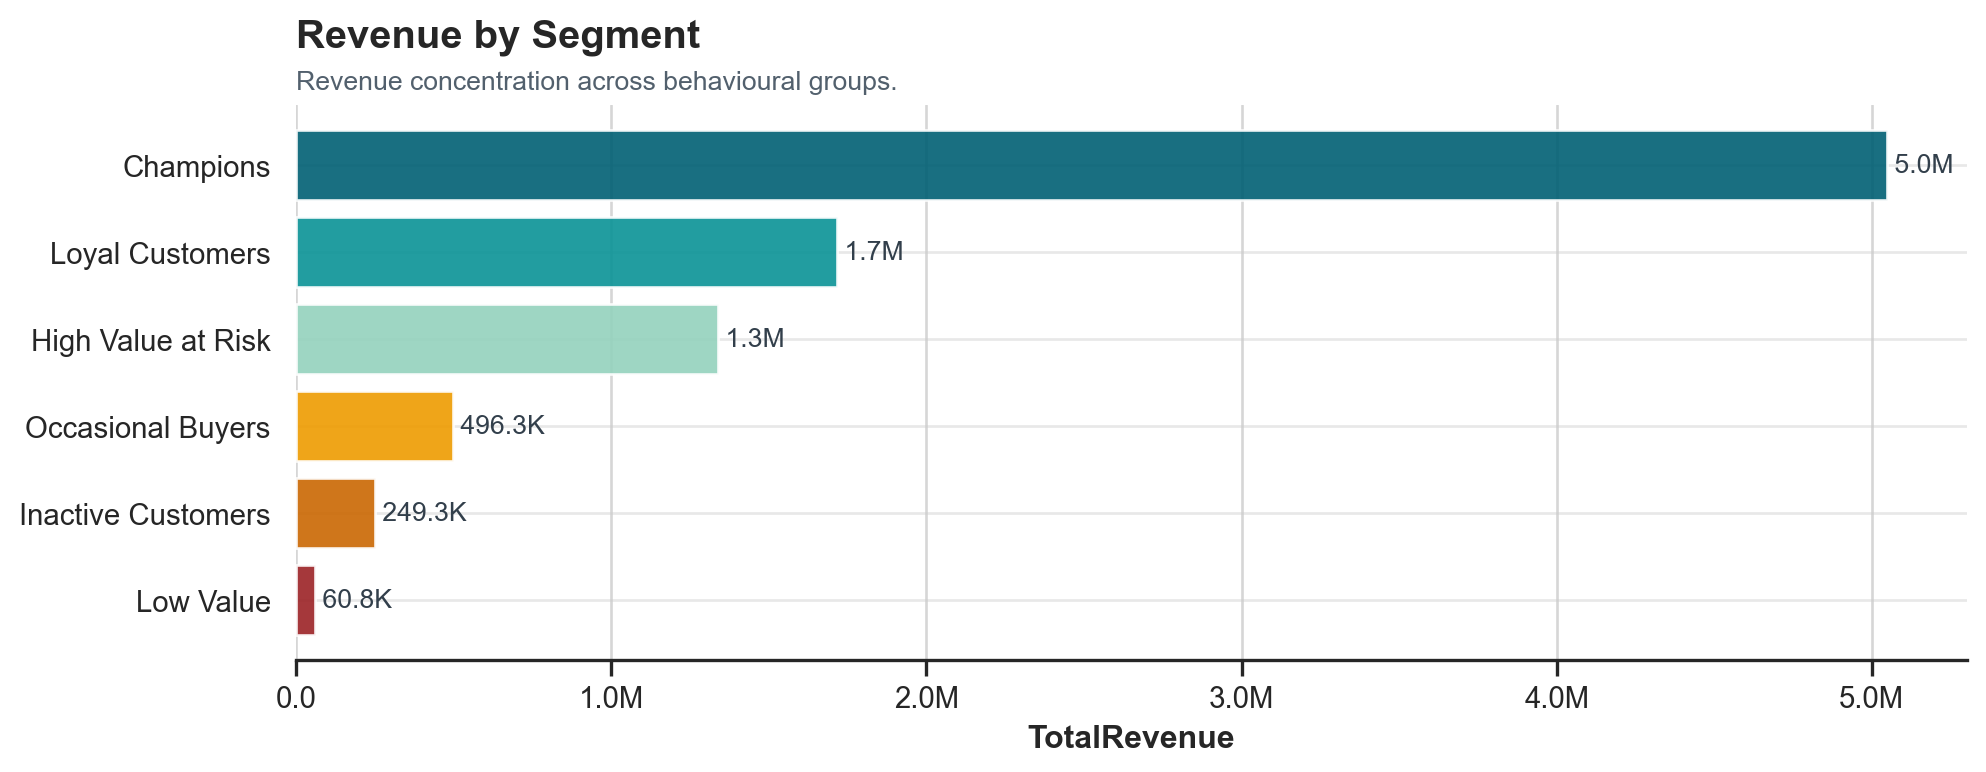

In [22]:
barh(
    profile.sort_values("TotalRevenue"),
    "SegmentName", "TotalRevenue",
    "Revenue by Segment",
    "Revenue concentration across behavioural groups.",
    color_col="Cluster", cmap=cluster_colors,
)

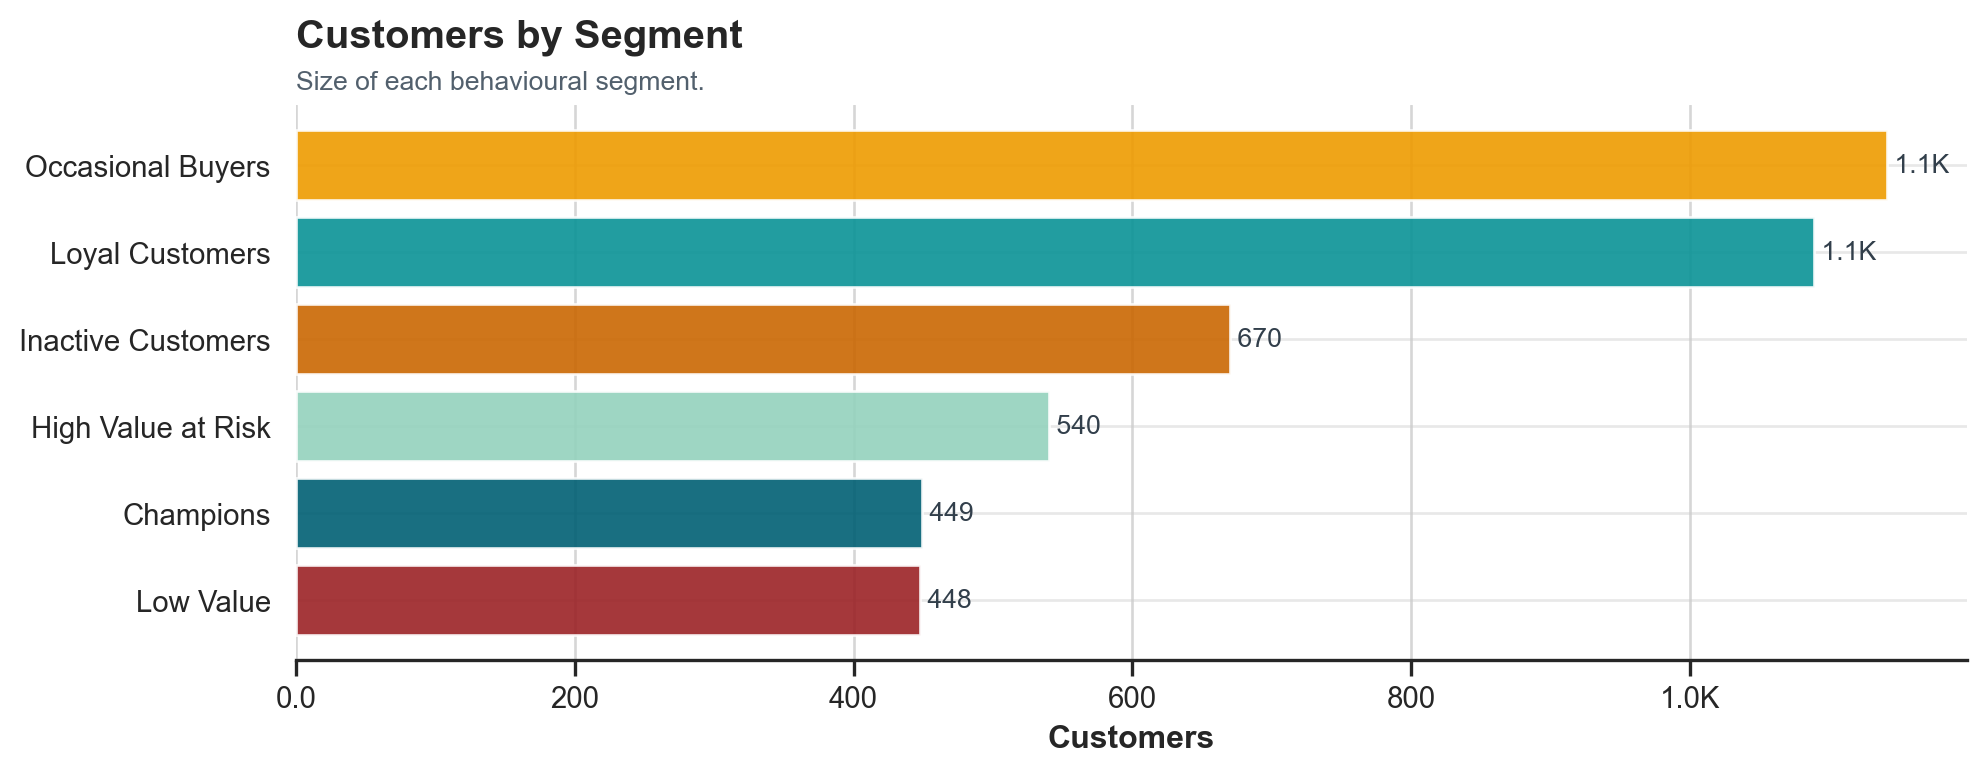

In [ ]:
barh(
    profile.sort_values("Customers"),
    "SegmentName", "Customers",
    "Customers by Segment",
    "Size of each behavioural segment.",
    color_col="Cluster", cmap=cluster_colors,
)

<span style="color:steelblue; text-align: left">

## Next Best Action (Heuristic)
</span>

Next Best Action transforms segmentation into operational decisions. The first version below is a heuristic recommendation by segment, useful for initial managerial reading. The notebook then evolves this logic into a predictive and prescriptive layer, in which the action is chosen by simulated expected profit [Rust and Verhoef, 2005; Bertsimas and Kallus, 2019].


In [24]:
next_action_summary = rfm.groupby(
    ["SegmentName", "NextBestAction"], as_index=False
).agg(
    Customers=("Customer ID", "count"),
    TotalRevenue=("Monetary", "sum"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
).sort_values("TotalRevenue", ascending=False)
next_action_summary["RevenueShare"] = (
    next_action_summary["TotalRevenue"] / next_action_summary["TotalRevenue"].sum() * 100
)
display(next_action_summary)
display(
    rfm[[
        "Customer ID", "Cluster", "SegmentName",
        "Recency", "Frequency", "Monetary", "AverageTicket", "UniqueProducts",
        "NextBestAction",
    ]].head(10)
)

,SegmentName,NextBestAction,Customers,TotalRevenue,AvgRecency,AvgFrequency,RevenueShare
0,Champions,"Offer VIP program, early access and exclusive ...",449,5049204.49,16.16,17.41,56.66
4,Loyal Customers,Encourage cross-sell and bundles.,1089,1716135.50,36.36,5.37,19.26
1,High Value at Risk,Prioritize reactivation campaigns and personal...,540,1339679.91,87.92,2.18,15.03
5,Occasional Buyers,Second-purchase campaigns and low-cost coupons.,1142,496295.36,55.91,1.86,5.57
2,Inactive Customers,Targeted reactivation or low priority.,670,249271.17,271.27,1.35,2.80
3,Low Value,Low-cost marketing automation.,448,60821.47,137.26,1.49,0.68


,Customer ID,Cluster,SegmentName,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,NextBestAction
0,12346,5,High Value at Risk,326,1,77183.60,77183.60,1,Prioritize reactivation campaigns and personal...
1,12347,1,Champions,2,7,4310.00,615.71,103,"Offer VIP program, early access and exclusive ..."
2,12348,5,High Value at Risk,75,4,1797.24,449.31,22,Prioritize reactivation campaigns and personal...
3,12349,5,High Value at Risk,19,1,1757.55,1757.55,73,Prioritize reactivation campaigns and personal...
4,12350,2,Inactive Customers,310,1,334.40,334.40,17,Targeted reactivation or low priority.
5,12352,4,Loyal Customers,36,8,2506.04,313.25,59,Encourage cross-sell and bundles.
6,12353,3,Low Value,204,1,89.00,89.00,4,Low-cost marketing automation.
7,12354,5,High Value at Risk,232,1,1079.40,1079.40,58,Prioritize reactivation campaigns and personal...
8,12355,2,Inactive Customers,214,1,459.40,459.40,13,Targeted reactivation or low priority.
9,12356,5,High Value at Risk,23,3,2811.43,937.14,53,Prioritize reactivation campaigns and personal...


<span style="color:steelblue; text-align: left">

## From Predictive to Prescriptive Analytics
</span>

Segmentation answers **who the customers are** and what behavioral patterns appear in the data. The supervised model answers **what is the probability of future repurchase**. The prescriptive layer answers **which action maximizes expected value** given this scenario.

This evolution brings the project closer to the framework of Bertsimas and Kallus [Bertsimas and Kallus, 2019]: `X` represents the observed customer data, `Y` represents future repurchase, `z` represents the incentive or campaign decision, and the objective function chooses the action that maximizes expected profit.

Important: the simulation below **does not estimate real causal effects** of the incentive. The uplift values are business hypotheses to demonstrate the prescriptive mechanics. In production, the incremental effect of each campaign should be validated through A/B testing or uplift modeling [Imbens and Rubin, 2015].


<span style="color:steelblue; text-align: left">

## 10. Predictive Layer — Repurchase Probability
</span>

To avoid data leakage, the dataset is split by time. Features are built only from purchases prior to the cutoff date. The target `repurchase_90d` observes the 90 days following the cutoff date and receives a value of 1 when the customer purchased again in that period.

This target represents **future repurchase** within a defined window, not classic supervised churn. The predictive step also separates an independent hold-out set before model validation. This hold-out is excluded from training and is used later to generate probabilities and feed the financial simulation without overfitting.

K-Means segments observed behavior; it does not directly estimate the chance of repurchase. To create the predictive layer, a supervised model uses pre-cutoff features to estimate `prob_repurchase_90d`. Logistic regression is used as an interpretable baseline; tree-based models are evaluated for comparison. The probability used in the prescriptive simulation is calibrated with `calibrate()` from `src.prediction`, since calibration reduces systematic bias, which is essential when probabilities enter financial calculations.


In [25]:
def mode_or_unknown(series: pd.Series) -> str:
    mode = series.dropna().mode()
    return str(mode.iloc[0]) if not mode.empty else "Unknown"

prediction_horizon_days = PREDICTION_HORIZON_DAYS
cutoff_date    = clean_df["InvoiceDate"].max() - pd.Timedelta(days=prediction_horizon_days)
target_end_date = cutoff_date + pd.Timedelta(days=prediction_horizon_days)

feature_df = clean_df.loc[clean_df["InvoiceDate"] < cutoff_date].copy()
target_df  = clean_df.loc[
    (clean_df["InvoiceDate"] >= cutoff_date) &
    (clean_df["InvoiceDate"] <= target_end_date)
].copy()

predictive_features = feature_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

predictive_features["AverageTicket"] = np.where(
    predictive_features["Frequency"] > 0,
    predictive_features["Monetary"] / predictive_features["Frequency"],
    0.0,
)

future_buyers = set(target_df["Customer ID"].unique())
predictive_features["repurchase_90d"] = (
    predictive_features["Customer ID"].isin(future_buyers).astype(int)
)

target_summary = pd.DataFrame({
    "Metric": [
        "Cutoff date",
        "End of target window",
        "Customers with pre-cutoff features",
        "Buyers in future window",
    ],
    "Value": [
        cutoff_date.strftime("%Y-%m-%d"),
        target_end_date.strftime("%Y-%m-%d"),
        fmt(predictive_features["Customer ID"].nunique()),
        fmt(predictive_features["repurchase_90d"].sum()),
    ],
})
target_distribution = (
    predictive_features["repurchase_90d"]
    .value_counts().rename_axis("repurchase_90d")
    .reset_index(name="Count")
)
target_distribution["Percentage"] = (
    target_distribution["Count"] / target_distribution["Count"].sum() * 100
)
display(target_summary)
display(target_distribution.sort_values("repurchase_90d"))
display(predictive_features.head())


,Metric,Value
0,Cutoff date,2011-09-10
1,End of target window,2011-12-09
2,Customers with pre-cutoff features,"3,370"
3,Buyers in future window,"1,921"


,repurchase_90d,Count,Percentage
1,0,1449,43.00
0,1,1921,57.00


,Customer ID,Recency,Frequency,Monetary,QuantityTotal,UniqueProducts,CountryMode,AverageTicket,repurchase_90d
0,12346,235,1,77183.60,74215,1,United Kingdom,77183.60,0
1,12347,39,5,2790.86,1590,82,Iceland,558.17,1
2,12348,158,3,1487.24,2124,22,Finland,495.75,1
3,12350,219,1,334.40,197,17,Norway,334.40,0
4,12352,171,5,1561.81,254,26,Norway,312.36,1


,Model,Sample,ROC_AUC,Recall,Precision,Accuracy,BrierScore
1,RandomForestClassifier,Validation,0.75,0.57,0.79,0.67,0.21
0,LogisticRegression,Validation,0.74,0.59,0.78,0.67,0.21
2,GradientBoostingClassifier,Validation,0.74,0.69,0.72,0.67,0.20


,Model,Sample,BrierScore
0,Without calibration,Validation,0.21
1,Calibrated,Validation,0.20


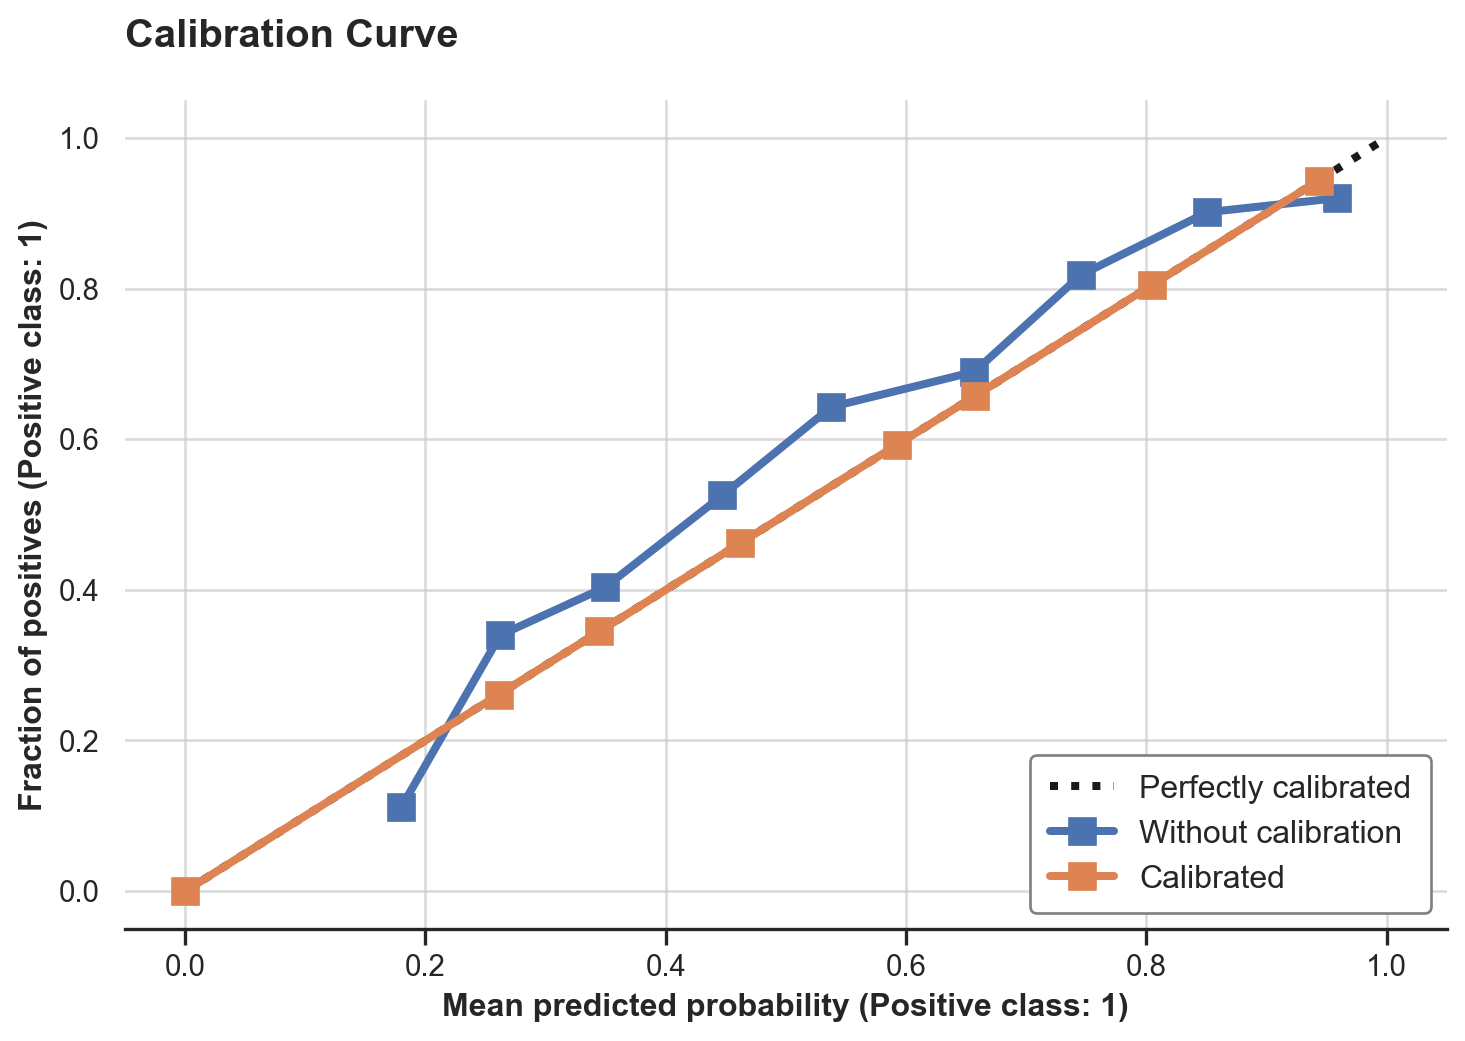

,Model,Sample,ROC_AUC,Recall,Precision,BrierScore
0,Without calibration,Hold-out,0.73,0.54,0.76,0.21
1,Calibrated,Hold-out,0.73,0.68,0.73,0.20


,Cluster,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,TotalRevenue,Customers,RevenuePercentage,PredictiveSegment
3,3,18.26,14.99,10157.55,640.22,160.24,2011193.99,198,56.00,Champions
2,2,42.31,4.83,1436.66,312.25,72.35,640749.91,446,17.84,Loyal Customers
0,0,93.82,1.93,2473.16,1416.28,60.36,566353.22,229,15.77,High Value at Risk
1,1,60.17,1.83,422.80,254.70,25.06,212247.54,502,5.91,Occasional Buyers
4,4,206.73,1.24,329.73,274.29,20.32,135519.55,411,3.77,Inactive Customers
5,5,119.56,1.31,115.98,94.95,6.26,25283.45,218,0.70,Low Value


,Customer ID,PredictiveSegment,repurchase_90d,prob_repurchase_90d,Recency,Frequency,Monetary,AverageTicket
1558,15039,Champions,1,1.00,1,38,18513.80,487.21
846,13798,Champions,1,1.00,2,42,29161.14,694.31
654,13468,Champions,1,1.00,2,29,4739.02,163.41
2476,16684,Champions,1,1.00,42,18,33883.50,1882.42
1322,14606,Champions,1,1.00,3,71,9564.19,134.71
3132,17865,Champions,1,0.94,17,12,7017.34,584.78
1018,14092,Champions,1,0.94,9,10,2745.42,274.54
3034,17696,Loyal Customers,1,0.94,17,7,1915.59,273.66
3248,18075,Loyal Customers,1,0.94,15,8,1957.75,244.72
2301,16359,Loyal Customers,1,0.94,4,7,1411.23,201.60


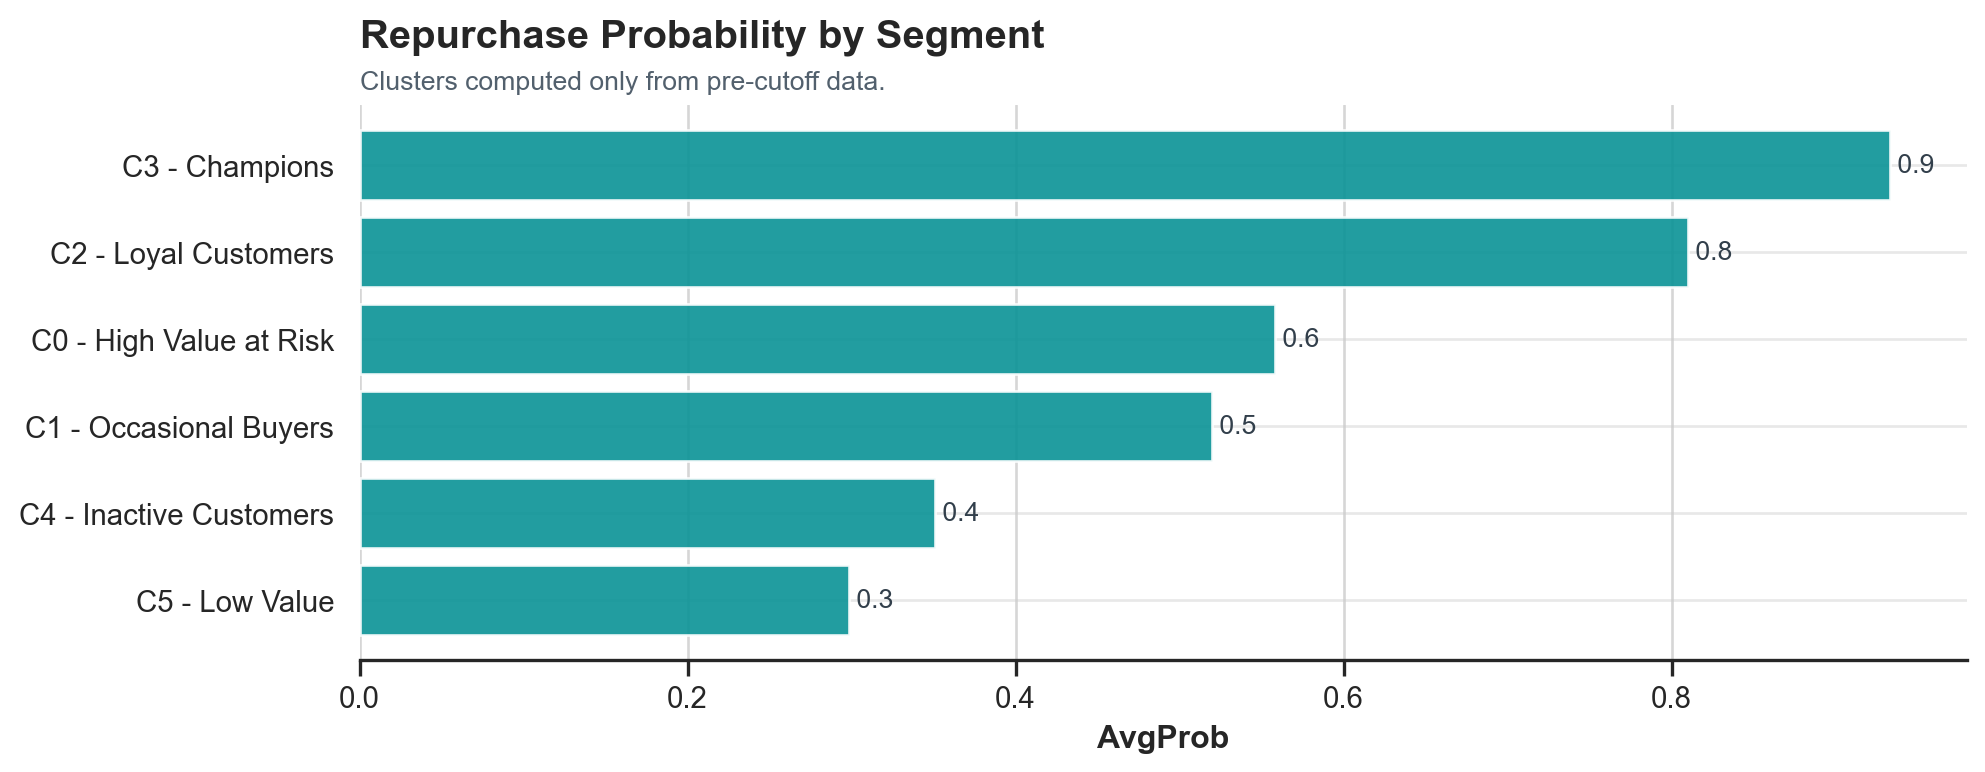

In [26]:
categorical_predictors = ["CountryMode"]
model_features = numeric_predictors + categorical_predictors

predictive_features = predictive_features.reset_index(drop=True)
modeling_df = predictive_features[
    ["Customer ID", "repurchase_90d"] + model_features
].copy().reset_index(drop=True)

X = modeling_df[model_features]
y = modeling_df["repurchase_90d"]
stratify_all = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y,
    test_size=HOLDOUT_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratify_all,
)
stratify_dev = y_dev if y_dev.nunique() == 2 and y_dev.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_dev, y_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=stratify_dev,
)

# ── Train candidate models ──────────────────────────────────────────────────
fitted_models = {}
metric_rows   = []
for model_name, estimator in make_model_specs(RANDOM_STATE).items():
    pipe = make_repurchase_pipeline(
        estimator,
        numeric_features=numeric_predictors,
        cluster_features=features,
        log_features=log_features,
        selected_k=selected_k,
    )
    pipe.fit(X_train, y_train)
    metric_rows.append(
        evaluate_classifier(model_name, "Validation", pipe, X_test, y_test)
    )
    fitted_models[model_name] = pipe

model_metrics = pd.DataFrame(metric_rows).sort_values("ROC_AUC", ascending=False)
display(model_metrics.round(4))

# ── Calibrate best model ────────────────────────────────────────────────────
baseline_model_name = "LogisticRegression"
baseline_pipeline   = fitted_models[baseline_model_name]
calibrated_model    = calibrate(baseline_pipeline, X_test, y_test)

calibration_metrics = pd.DataFrame([
    evaluate_classifier("Without calibration", "Validation",
                         baseline_pipeline, X_test, y_test),
    evaluate_classifier("Calibrated",          "Validation",
                         calibrated_model,      X_test, y_test),
])
display(calibration_metrics[["Model", "Sample", "BrierScore"]].round(4))

fig, ax = plt.subplots(figsize=(7.8, 5.6))
CalibrationDisplay.from_estimator(
    baseline_pipeline, X_test, y_test, n_bins=10, ax=ax, name="Without calibration"
)
CalibrationDisplay.from_estimator(
    calibrated_model, X_test, y_test, n_bins=10, ax=ax, name="Calibrated"
)
ax.set_title(t("Calibration Curve"), loc="left", fontsize=15, fontweight="bold")
ax.grid(alpha=0.7)
plt.tight_layout()
plt.show()

# ── Hold-out evaluation ─────────────────────────────────────────────────────
holdout_metrics = pd.DataFrame([
    evaluate_classifier("Without calibration", "Hold-out",
                         baseline_pipeline, X_hold, y_hold),
    evaluate_classifier("Calibrated",          "Hold-out",
                         calibrated_model,      X_hold, y_hold),
])
display(holdout_metrics[["Model","Sample","ROC_AUC","Recall","Precision","BrierScore"]].round(4))

# ── Build holdout_predictions with segment labels ───────────────────────────
cluster_segmenter = KMeansClusterAdder(
    cluster_features=features,
    log_features=log_features,
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
).fit(X_train)

train_clustered    = cluster_segmenter.transform(X_train)
train_profile_base = predictive_features.loc[X_train.index].copy()
train_profile_base["PredictiveCluster"] = (
    train_clustered["PredictiveCluster"].astype(int).to_numpy()
)

temporal_profile = train_profile_base.groupby("PredictiveCluster").agg(
    Cluster=("PredictiveCluster", "first"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AverageTicket=("AverageTicket", "mean"),
    UniqueProducts=("UniqueProducts", "mean"),
    TotalRevenue=("Monetary", "sum"),
    Customers=("Customer ID", "count"),
).reset_index(drop=True)
temporal_profile["RevenuePercentage"] = (
    temporal_profile["TotalRevenue"] / temporal_profile["TotalRevenue"].sum() * 100
)

temporal_names = segment_names(temporal_profile)
validate_segment_names(temporal_profile, temporal_names)
temporal_profile["PredictiveSegment"] = temporal_profile["Cluster"].map(temporal_names)
display(temporal_profile.sort_values("TotalRevenue", ascending=False))

holdout_predictions = predictive_features.loc[X_hold.index].copy()
holdout_clustered   = cluster_segmenter.transform(X_hold)
holdout_predictions["PredictiveCluster"] = (
    holdout_clustered["PredictiveCluster"].astype(int).to_numpy()
)
holdout_predictions["PredictiveSegment"] = (
    holdout_predictions["PredictiveCluster"].map(temporal_names)
)
holdout_predictions["prob_repurchase_90d"] = calibrated_model.predict_proba(X_hold)[:, 1]

# ── Merge probability into rfm for CRM export ───────────────────────────────
rfm = rfm.drop(columns=["prob_repurchase_90d"], errors="ignore").merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d"]],
    on="Customer ID",
    how="left",
)

display(
    holdout_predictions[[
        "Customer ID", "PredictiveSegment",
        "repurchase_90d", "prob_repurchase_90d",
        "Recency", "Frequency", "Monetary", "AverageTicket",
    ]].sort_values("prob_repurchase_90d", ascending=False).head(10)
)

# Repurchase probability by segment chart
prob_by_cluster = holdout_predictions.groupby(
    ["PredictiveCluster", "PredictiveSegment"], as_index=False
).agg(
    AvgProb=("prob_repurchase_90d", "mean"),
    Customers=("Customer ID", "count"),
)
prob_by_cluster["ClusterSegment"] = (
    "C" + prob_by_cluster["PredictiveCluster"].astype(str)
    + " - " + prob_by_cluster["PredictiveSegment"]
)
barh(
    prob_by_cluster.sort_values("AvgProb"),
    "ClusterSegment", "AvgProb",
    "Repurchase Probability by Segment",
    "Clusters computed only from pre-cutoff data.",
    PALETTE[1],
)

**Insight (repurchase by segment):** Average repurchase probability varies materially across segments, confirming that segment behavior carries predictive signal.
Higher-probability segments are candidates for margin-protective actions, while lower-probability groups require selective spend.
The dispersion supports individualized incentives instead of a uniform campaign.
These probabilities feed directly into expected-profit optimization in the prescriptive layer.


<span style="color:steelblue; text-align: left">

## 11. Prescriptive Layer — Incentive Simulation
</span>

The prescriptive layer evaluates possible actions `z` for each customer. Each action has an incentive cost and a heuristic uplift that varies by segment. The expected profit is: `adjusted_prob = min(base_prob + base_uplift × segment_multiplier, 1)`, `expected_revenue = adjusted_prob × Monetary`, `expected_profit = expected_revenue × MARGIN_RATE − incentive_cost`.

The values in `INCENTIVE_CATALOGUE` and `SEGMENT_UPLIFT_MULTIPLIER` are business simulation hypotheses, not estimated causal effects. Replace with empirical A/B test results or an uplift model before production use.


In [27]:
simulation    = simulate_actions(
    holdout_predictions,
    prob_col="prob_repurchase_90d",
    segment_col="PredictiveSegment",
    revenue_col="Monetary",
)
prescriptive_df = select_best_action(simulation)

# Merge back contextual columns needed for recommendations and CRM export
prescriptive_df = prescriptive_df.merge(
    holdout_predictions[[
        "Customer ID", "PredictiveSegment", "PredictiveCluster",
        "prob_repurchase_90d", "Monetary", "AverageTicket",
    ]],
    on="Customer ID",
    how="left",
)

action_summary = prescriptive_df.groupby(
    ["BestAction", "RecommendedAction"], as_index=False
).agg(
    Customers=("Customer ID", "count"),
    TotalExpectedProfit=("ExpectedProfit", "sum"),
    TotalIncrementalProfit=("IncrementalProfit", "sum"),
    AvgProb=("prob_repurchase_90d", "mean"),
).sort_values("TotalIncrementalProfit", ascending=False)

display(action_summary.round(4))
display(
    simulation[[
        "Customer ID", "Action", "incentive_cost",
        "AdjustedProb", "ExpectedRevenue", "ExpectedProfit", "IncrementalProfit",
    ]].head(12)
)


,BestAction,RecommendedAction,Customers,TotalExpectedProfit,TotalIncrementalProfit,AvgProb
0,High Incentive,High Incentive — $10 voucher,235,71296.00,10069.42,0.62
2,Medium Incentive,Medium Incentive — $5 voucher,103,82595.03,4662.36,0.75
1,Low Incentive,Low Incentive — $2 voucher,15,648.24,1.75,0.34
3,No Action,No Action,153,37266.94,0.00,0.38


,Customer ID,Action,incentive_cost,AdjustedProb,ExpectedRevenue,ExpectedProfit,IncrementalProfit
0,14373,No Action,0.00,0.00,0.00,0.00,0.00
1,14373,Low Incentive,2.00,0.02,1.38,-1.52,-1.52
2,14373,Medium Incentive,5.00,0.04,3.22,-3.87,-3.87
3,14373,High Incentive,10.00,0.07,5.51,-8.07,-8.07
4,16008,No Action,0.00,0.35,48.24,16.88,0.00
5,16008,Low Incentive,2.00,0.36,50.74,15.76,-1.12
6,16008,Medium Incentive,5.00,0.39,54.08,13.93,-2.95
7,16008,High Incentive,10.00,0.42,58.26,10.39,-6.49
8,17616,No Action,0.00,0.41,235.20,82.32,0.00
9,17616,Low Incentive,2.00,0.43,245.48,83.92,1.60


<span style="color:steelblue; text-align: left">

## 12. Budget-Constrained Optimization
</span>

The optimal decision per customer ignores the fact that the marketing budget is finite. In this step, the prescriptive recommendation is submitted to `BUDGET_TOTAL` and a greedy selection prioritizes customers with the highest expected incremental profit until the available budget is consumed. This greedy allocation is a heuristic — for exact optimization use Integer Linear Programming (ILP).

**Note on scope:** The incentive simulation and budget allocation operate on the hold-out set (≈15% of total customers), which is the subset for which the model generated probabilities on data never seen during training. This ensures expected profits are not inflated by overfitting. In production, the calibrated model would be applied to the entire active customer base.

The section also compares a margin-based objective function (using `MARGIN_RATE`) and three scenarios: no action, uniform campaign and individual prescription.

In practice, greedy allocation typically captures 85-95% of the optimal ILP solution for instances of this size. For exact optimization, see the ILP formulation listed in Future Improvements.


,Metric,Value
0,Simulation scope,Hold-out set
1,Total budget,"10,000.00"
2,Budget used,"2,895.00"
3,Remaining budget,"7,105.00"
4,Customers exported,353
5,Expected incremental profit,"14,733.53"


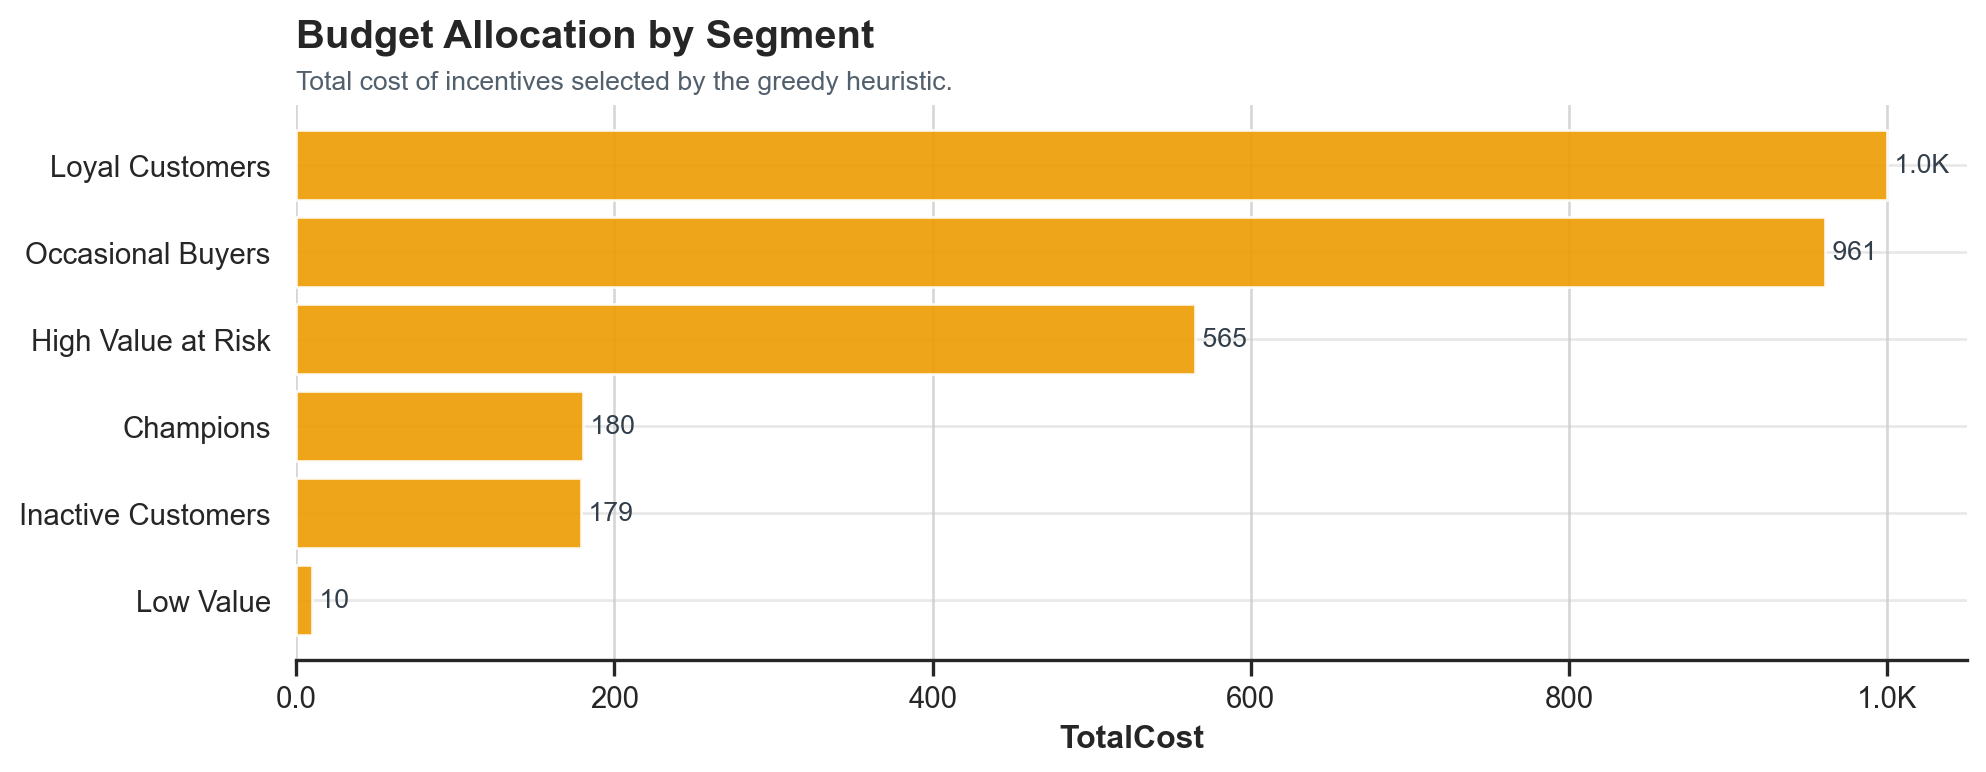

,Metric,Value
0,Customers evaluated,506
1,Customers with changed action,134
2,Percentage with changed action,26.5%


,Scenario,TotalProfit,TotalCost,GainVsBaseline,ROI
0,A — No action,177072.67,0.00,0.00,NaN
1,B — Uniform campaign (medium),187347.77,2530.00,10275.10,4.06
2,C — Prescription per customer,42604.44,2046.00,-134468.23,-65.72


,BudgetPercentile,Budget,IncrementalProfit,CustomersServed,ROI
0,25%,708.98,9331.37,84.00,13.20
1,50%,1417.96,13082.56,170.00,9.23
2,75%,2186.02,14457.05,250.00,6.62
3,100%,2895.00,14733.53,353.00,5.09


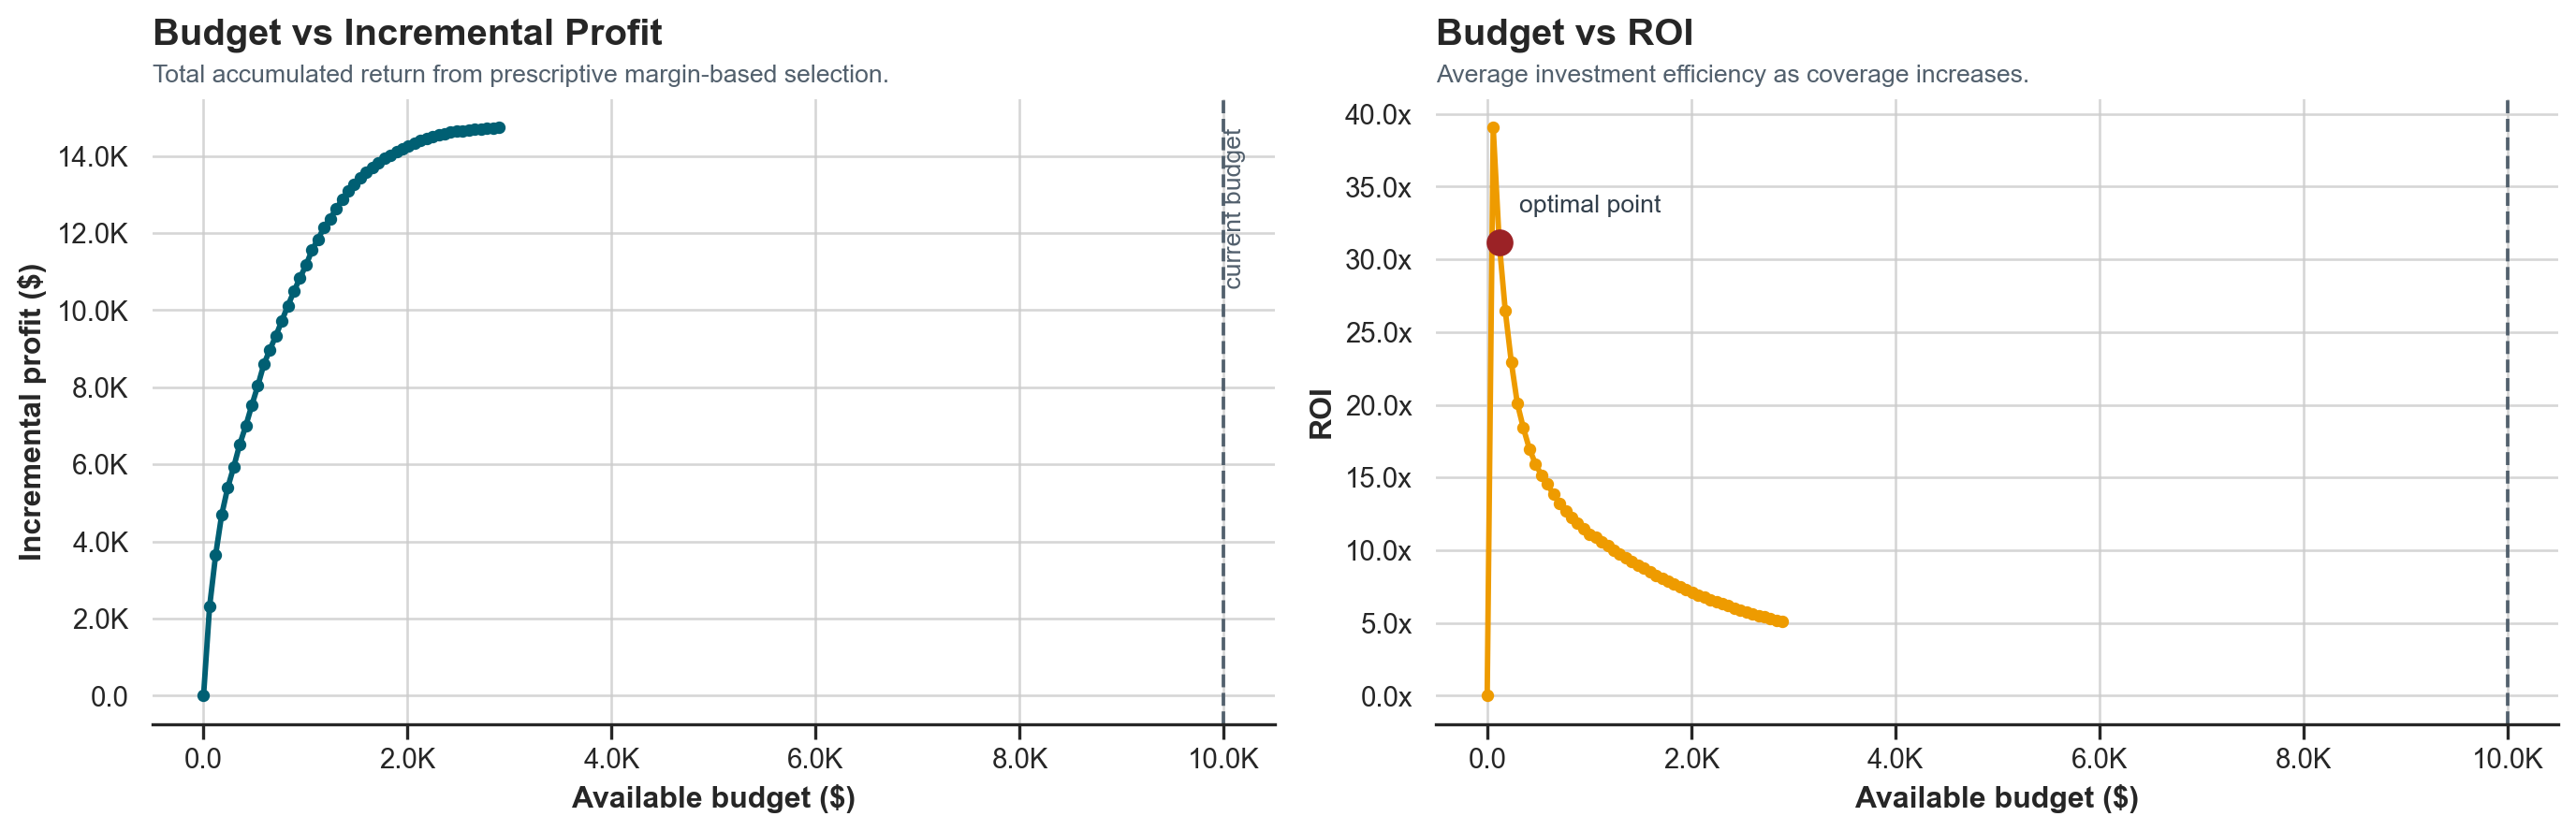

In [28]:
# ── Budget allocation ─────────────────────────────────────────────────────
prescriptive_with_budget = allocate_budget(prescriptive_df, budget=BUDGET_TOTAL)

budget_summary = prescriptive_with_budget.groupby("PredictiveSegment", as_index=False).agg(
    Customers=("Customer ID", "count"),
    Allocated=("BudgetAllocated", "sum"),
    TotalCost=("incentive_cost", lambda x: x[prescriptive_with_budget.loc[x.index, "BudgetAllocated"]].sum()),
    TotalIncrementalProfit=("IncrementalProfit", lambda x: x[prescriptive_with_budget.loc[x.index, "BudgetAllocated"]].sum()),
).sort_values("TotalIncrementalProfit", ascending=False)

allocated_df = prescriptive_with_budget.loc[prescriptive_with_budget["BudgetAllocated"]]
remaining_budget = BUDGET_TOTAL - allocated_df["incentive_cost"].sum()
budget_overview = pd.DataFrame({
    "Metric": [
        "Simulation scope",
        "Total budget",
        "Budget used",
        "Remaining budget",
        t("Customers exported: {}").split(":")[0],
        "Expected incremental profit",
    ],
    "Value": [
        "Hold-out set",
        fmt(BUDGET_TOTAL, 2),
        fmt(allocated_df["incentive_cost"].sum(), 2),
        fmt(remaining_budget, 2),
        fmt(len(allocated_df)),
        fmt(allocated_df["IncrementalProfit"].sum(), 2),
    ],
})
display(budget_overview)

barh(
    budget_summary.sort_values("TotalCost"),
    "PredictiveSegment", "TotalCost",
    "Budget Allocation by Segment",
    "Total cost of incentives selected by the greedy heuristic.",
    PALETTE[3],
)

# ── Margin-based objective comparison ─────────────────────────────────────
decision_simulation = simulation.merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d", "AverageTicket"]],
    on="Customer ID",
    how="left",
)
decision_simulation["expected_margin"] = (
    decision_simulation["AdjustedProb"] * decision_simulation["AverageTicket"] * MARGIN_RATE
)
decision_simulation["expected_profit_margin"] = (
    decision_simulation["expected_margin"] - decision_simulation["incentive_cost"]
)
margin_best_idx = decision_simulation.groupby("Customer ID")["expected_profit_margin"].idxmax()
prescriptive_margin_df = decision_simulation.loc[margin_best_idx].copy()
prescriptive_margin_df = prescriptive_margin_df.rename(columns={
    "Action": "BestActionMargin",
    "expected_profit_margin": "BestMarginProfit",
})

margin_comparison = prescriptive_df[["Customer ID", "BestAction"]].merge(
    prescriptive_margin_df[["Customer ID", "BestActionMargin"]],
    on="Customer ID",
    how="left",
)
margin_comparison["action_changed"] = (
    margin_comparison["BestAction"] != margin_comparison["BestActionMargin"]
)
display(pd.DataFrame({
    "Metric": ["Customers evaluated", "Customers with changed action",
               "Percentage with changed action"],
    "Value": [
        len(margin_comparison),
        int(margin_comparison["action_changed"].sum()),
        f"{margin_comparison['action_changed'].mean()*100:.1f}%",
    ],
}))

# ── Scenario comparison ───────────────────────────────────────────────────
UNIFORM_UPLIFT = 0.07
UNIFORM_COST   = 5.00

scenario_a_profit = (
    holdout_predictions["prob_repurchase_90d"] *
    holdout_predictions["Monetary"] * MARGIN_RATE
).sum()
scenario_b_profit = (
    (holdout_predictions["prob_repurchase_90d"] + UNIFORM_UPLIFT).clip(upper=1) *
    holdout_predictions["Monetary"] * MARGIN_RATE - UNIFORM_COST
).sum()
scenario_c_profit = prescriptive_margin_df["BestMarginProfit"].sum()

scenario_summary = pd.DataFrame({
    "Scenario": ["A — No action", "B — Uniform campaign (medium)", "C — Prescription per customer"],
    "TotalProfit": [scenario_a_profit, scenario_b_profit, scenario_c_profit],
    "TotalCost":   [0.0, UNIFORM_COST * len(holdout_predictions),
                    prescriptive_margin_df["incentive_cost"].sum()],
})
scenario_summary["GainVsBaseline"] = (
    scenario_summary["TotalProfit"] - scenario_summary.loc[0, "TotalProfit"]
)
scenario_summary["ROI"] = np.where(
    scenario_summary["TotalCost"] > 0,
    scenario_summary["GainVsBaseline"] / scenario_summary["TotalCost"],
    np.nan,
)
display(scenario_summary.round(2))

# ── Budget curve ───────────────────────────────────────────────────────────
budget_curve_df, budget_breakpoints = build_budget_curve(prescriptive_df)
display(budget_breakpoints.round(2))

positive_curve = budget_curve_df.loc[budget_curve_df["ActualCost"] > 0].copy()
if positive_curve.empty:
    optimal_budget_point = budget_curve_df.iloc[[0]].copy()
else:
    positive_curve["ROI_Delta"] = positive_curve["ROI"].diff()
    if positive_curve["ROI_Delta"].notna().any():
        optimal_idx = positive_curve["ROI_Delta"].idxmin()
    else:
        optimal_idx = positive_curve["ROI"].idxmax()
    optimal_budget_point = budget_curve_df.loc[[optimal_idx]].copy()

budget_curves(budget_curve_df, BUDGET_TOTAL, optimal_budget_point)


**Insight (budget and scenarios):** Budget allocation concentrates spend where incremental profit is highest, creating a non-linear ROI profile as coverage expands.
Scenario comparison typically shows individualized prescription outperforming uniform treatment under the same budget.
In practice, greedy allocation typically captures 85-95% of the optimal ILP solution for instances of this size.
For exact optimization, see the ILP formulation listed in Future Improvements.


<span style="color:steelblue; text-align: left">

## 13. Sensitivity Analysis
</span>

Predictive models are not perfect. This section simulates what happens to the total expected profit when the real probabilities differ from the estimated ones by up to ±15 percentage points. A robust model should be profitable even under realistic perturbations. If the expected profit enters negative territory with a shift of only -5pp, the incentive policy is too fragile for production.


,NoiseDelta,TotalIncrementalProfit
0,-0.15,140520.04
1,-0.10,151736.13
2,-0.05,162954.09
3,0.00,174177.67
4,0.05,183829.17
5,0.10,190356.67
6,0.15,195979.86


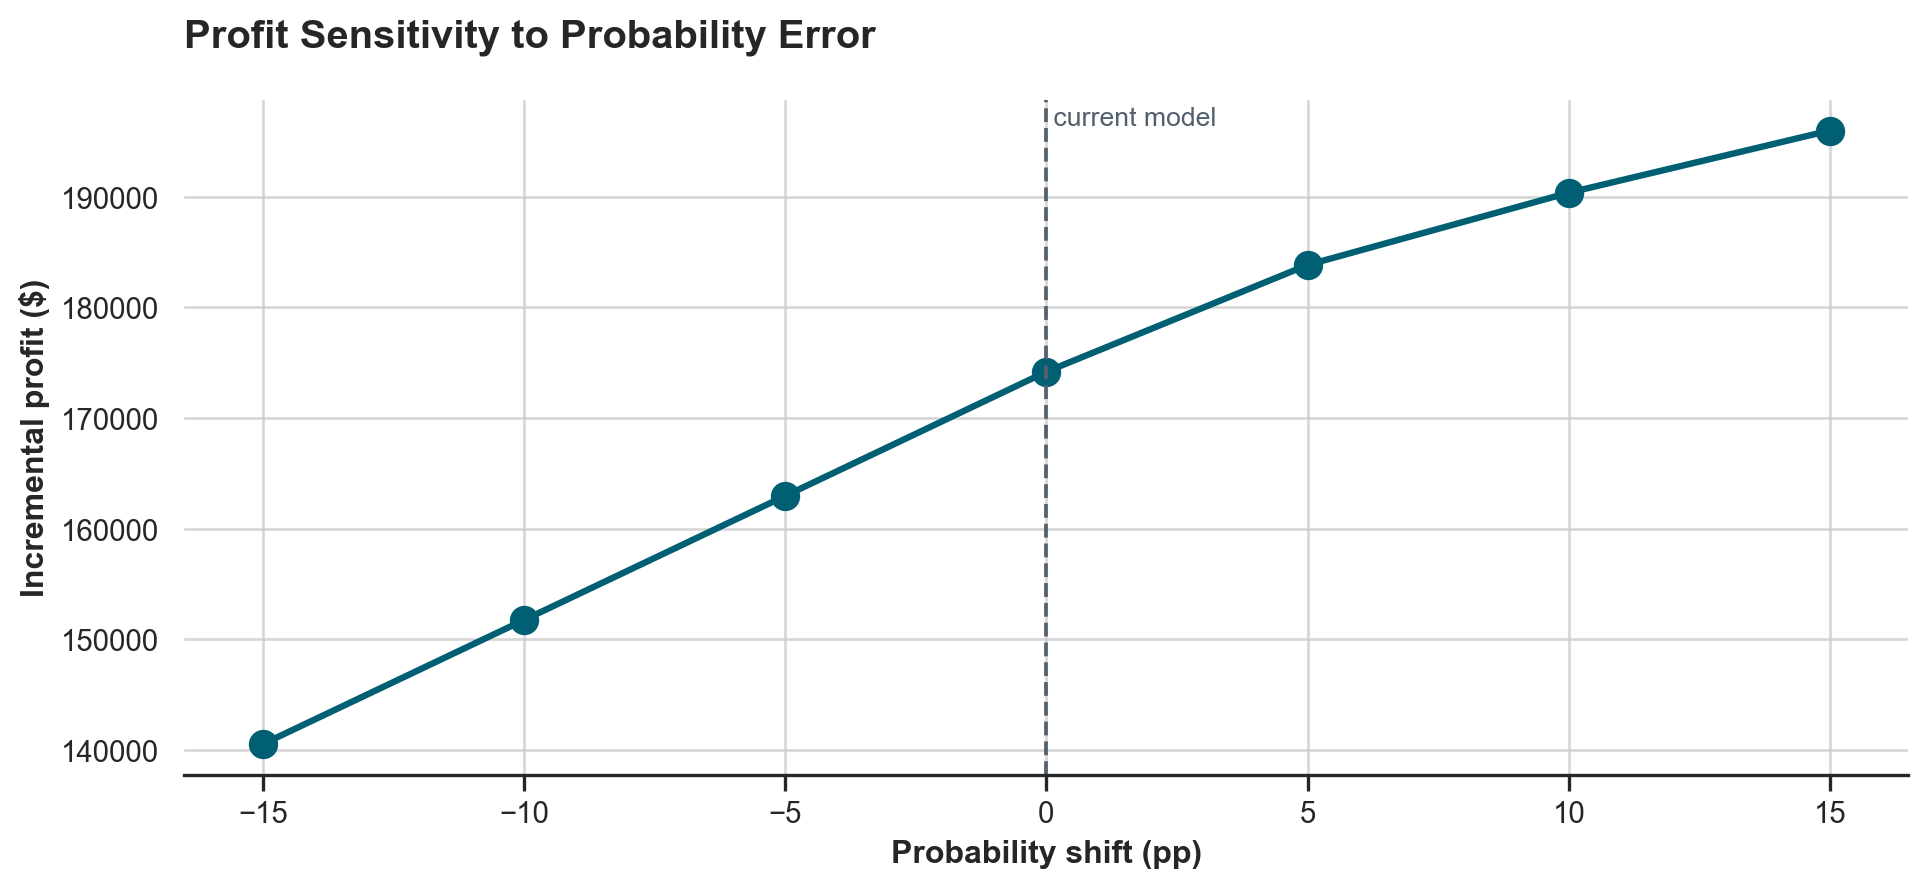

In [29]:
prescriptive_for_sensitivity = prescriptive_df[
    ["Customer ID", "incentive_cost"]
].merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d", "Monetary"]],
    on="Customer ID",
    how="left",
)
sensitivity_df = sensitivity_analysis(prescriptive_for_sensitivity)
display(sensitivity_df.round(2))

fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.plot(
    sensitivity_df["NoiseDelta"] * 100,
    sensitivity_df["TotalIncrementalProfit"],
    marker="o", linewidth=2.4, color=PALETTE[0],
)
ax.axvline(0, color="#52606D", linestyle="--", linewidth=1.4)
ax.text(0, sensitivity_df["TotalIncrementalProfit"].max(),
        " current model", ha="left", va="bottom", fontsize=10, color="#52606D")
ax.set_title("Profit Sensitivity to Probability Error",
             loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Probability shift (pp)")
ax.set_ylabel(t("Incremental profit ($)"))
ax.grid(alpha=0.8)
plt.tight_layout()
plt.show()


**Insight (sensitivity):** Total incremental profit declines as probability estimates are stressed downward, quantifying decision risk under model error.
The slope around 0 pp indicates how sensitive campaign economics are to calibration deviations.
If profit remains positive under moderate negative shocks, the policy is more robust for production rollout.
This stress test complements point estimates with a resilience view.


<span style="color:steelblue; text-align: left">

## "Do Nothing" Decision
</span>

Naive models send campaigns to everyone. Mature models know when **not acting** is the best decision. This section explicitly quantifies the customers for whom no incentive generates a positive return, and how much budget is preserved by this decision.


,Group,Customers,PercentageOfBase,BudgetSaved,BudgetInvested,TotalIncrementalProfit
0,No incentive,153,30.24,765.00,0.00,0.00
1,With incentive,353,69.76,0.00,2895.00,14733.53


,PredictiveSegment,Customers,BudgetSaved
1,Inactive Customers,76,380.00
2,Low Value,45,225.00
3,Occasional Buyers,27,135.00
0,Champions,5,25.00


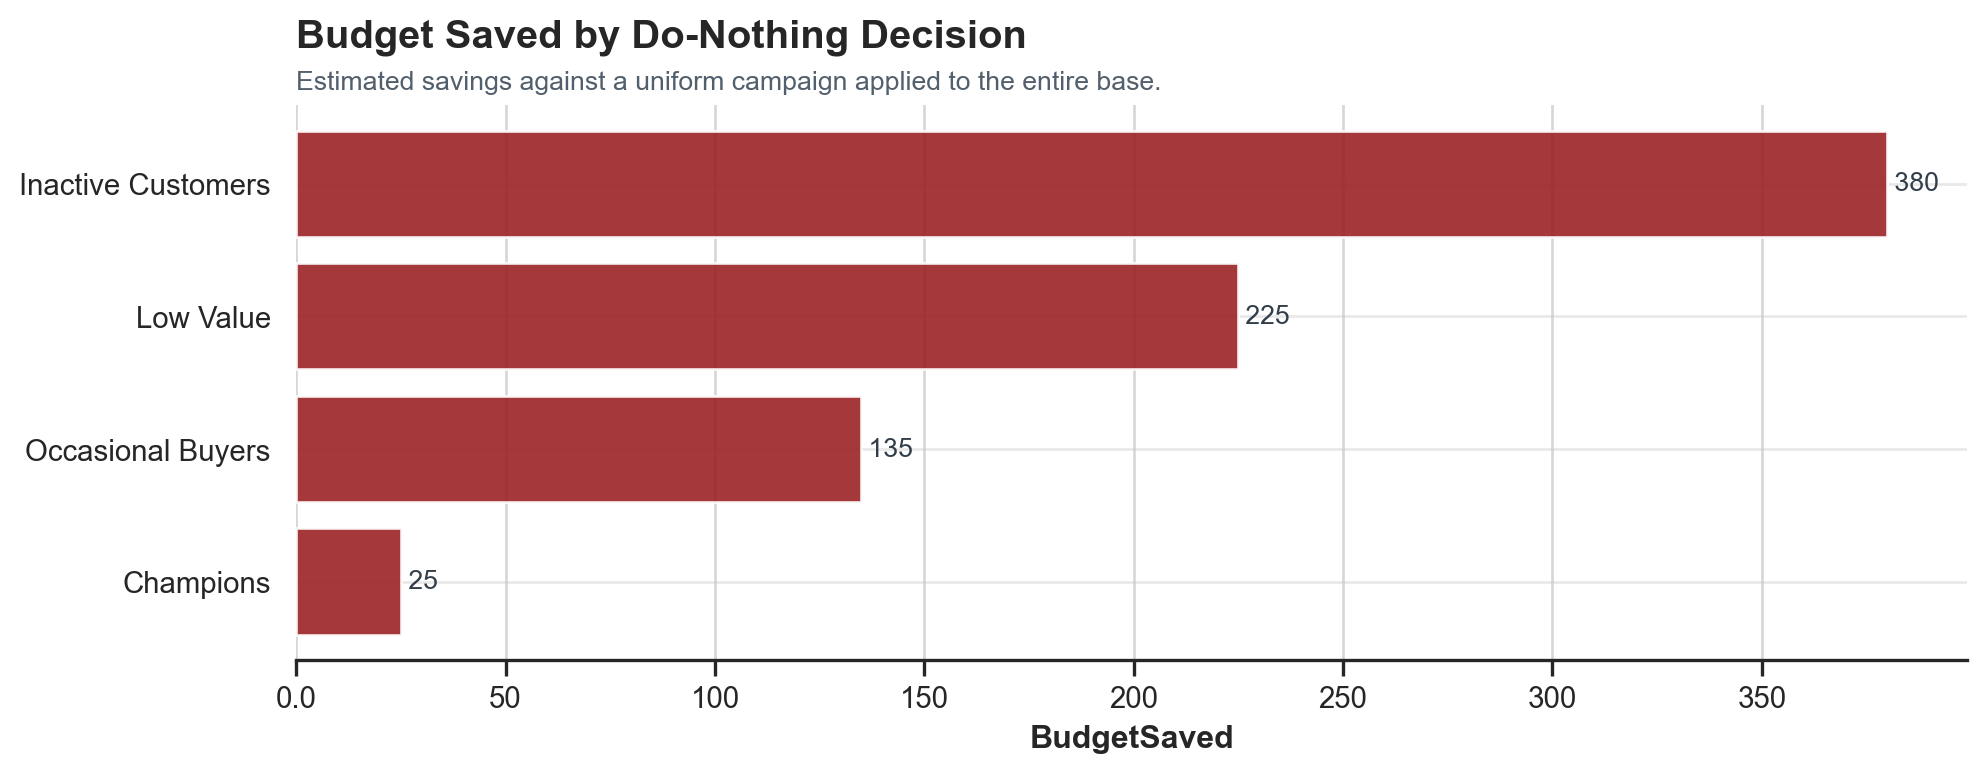

In [30]:
no_action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] == "No Action") |
    (prescriptive_df["IncrementalProfit"] <= 0)
].copy()
action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action") &
    (prescriptive_df["IncrementalProfit"] > 0)
].copy()

UNIFORM_COST_LOCAL = 5.00
no_action_clients["budget_avoided"] = UNIFORM_COST_LOCAL
action_clients["budget_avoided"]    = 0.0

no_action_summary = pd.DataFrame({
    "Group": ["No incentive", "With incentive"],
    "Customers": [len(no_action_clients), len(action_clients)],
    "PercentageOfBase": [
        len(no_action_clients) / len(prescriptive_df) * 100,
        len(action_clients) / len(prescriptive_df) * 100,
    ],
    "BudgetSaved":  [no_action_clients["budget_avoided"].sum(), 0],
    "BudgetInvested": [0, action_clients["incentive_cost"].sum()],
    "TotalIncrementalProfit": [
        no_action_clients["IncrementalProfit"].sum(),
        action_clients["IncrementalProfit"].sum(),
    ],
})
display(no_action_summary.round(2))

no_action_by_segment = (
    no_action_clients.groupby("PredictiveSegment", as_index=False)
    .agg(Customers=("Customer ID", "count"),
         BudgetSaved=("budget_avoided", "sum"))
    .sort_values("Customers", ascending=False)
)
display(no_action_by_segment.round(2))
barh(
    no_action_by_segment.sort_values("BudgetSaved"),
    "PredictiveSegment", "BudgetSaved",
    "Budget Saved by Do-Nothing Decision",
    "Estimated savings against a uniform campaign applied to the entire base.",
    PALETTE[5],
)


<span style="color:steelblue; text-align: left">

## 14. Next Best Action — Final Recommendations
</span>

The final decision tests all available actions for each customer and selects the one with the highest `ExpectedProfit`. The incremental gain compares the best action against `No Action`. The `build_recommendation()` function from `src.prescriptive` translates each decision into an executive sentence respecting the active language via `t()`.


In [ ]:
prescriptive_df["PrescriptiveNextBestAction"] = prescriptive_df.apply(
    build_recommendation, axis=1
)
prescriptive_df["ClusterSegment"] = (
    "C" + prescriptive_df["PredictiveCluster"].astype(str)
    + " - " + prescriptive_df["PredictiveSegment"]
)

# Distribution of best action by cluster
cluster_action_counts = pd.crosstab(
    prescriptive_df["ClusterSegment"],
    prescriptive_df["RecommendedAction"],
)
cluster_order = (
    holdout_predictions.groupby(["PredictiveCluster", "PredictiveSegment"])
    .size().reset_index(name="n")
    .sort_values("PredictiveCluster")
)
cluster_order["ClusterSegment"] = (
    "C" + cluster_order["PredictiveCluster"].astype(str)
    + " - " + cluster_order["PredictiveSegment"]
)
cluster_action_counts = cluster_action_counts.reindex(
    cluster_order["ClusterSegment"].tolist()
).fillna(0)

action_order = list(prescriptive_df["RecommendedAction"].value_counts().index)
action_palette_map = {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(action_order)}

fig, ax = plt.subplots(figsize=(10.8, 5.8))
left = np.zeros(len(cluster_action_counts))
for action in action_order:
    if action not in cluster_action_counts.columns:
        continue
    values = cluster_action_counts[action].to_numpy()
    ax.barh(cluster_action_counts.index, values, left=left,
            color=action_palette_map[action], alpha=0.88, label=action)
    left += values
ax.set_title("Best Recommended Action by Temporal Cluster",
             loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel(t("Customers"))
ax.grid(axis="x", alpha=0.8)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

barh(
    action_summary.sort_values("TotalIncrementalProfit"),
    "RecommendedAction", "TotalIncrementalProfit",
    "Total Incremental Profit by Action Type",
    "Difference between best action and No Action, based on uplift hypotheses.",
    PALETTE[3],
)

# Scatter: prob vs monetary coloured by action
fig, ax = plt.subplots(figsize=(10.8, 5.8))
for action in action_order:
    group = prescriptive_df.loc[prescriptive_df["RecommendedAction"] == action]
    if group.empty:
        continue
    ax.scatter(group["prob_repurchase_90d"], group["Monetary"],
               s=24, alpha=0.55, color=action_palette_map[action], label=action)
ax.set_title("Repurchase Probability vs Monetary",
             loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel(t("Repurchase probability"))
ax.set_ylabel(t("Monetary ($)"))
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(alpha=0.7)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    prescriptive_df[[
        "Customer ID", "PredictiveSegment", "prob_repurchase_90d",
        "BestAction", "RecommendedAction", "ExpectedProfit",
        "IncrementalProfit", "PrescriptiveNextBestAction",
    ]].sort_values("IncrementalProfit", ascending=False).head(10)
)


<span style="color:steelblue; text-align: left">

## 15. CRM Export
</span>

The `crm_next_best_action.csv` file consolidates, for each hold-out customer,
the segment, the recommended action, the expected profit and the executive description of the
Next Best Action. The `priority_rank` column globally ranks customers by
incremental profit — rank 1 is the customer that generates the most return if they receive an incentive.

The file is ready for direct import into CRM tools, email marketing automation
or service queue prioritization.


In [ ]:
crm_output = build_crm_export(rfm, prescriptive_df)

EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
crm_output.to_csv(EXPORT_PATH, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(t("Export generated: {}").format(EXPORT_PATH))
print(t("Customers exported: {}").format(fmt(len(crm_output))))
print(t("Segments covered: {}").format(crm_output["segment_name"].nunique()))

display(crm_output.head(10))
display(
    crm_output.groupby("segment_name", as_index=False).agg(
        Customers=("customer_id", "count"),
        TotalIncrementalProfit=("incremental_profit", "sum"),
        MinPriority=("priority_rank", "min"),
        MaxPriority=("priority_rank", "max"),
    ).sort_values("TotalIncrementalProfit", ascending=False)
)


<span style="color:steelblue; text-align: left">

## 16. Implemented Improvements
</span>

- **Problem 1:** `PredictiveCluster` is now generated inside the `Pipeline`, with `KMeans.fit()` only on training and `predict()` for validation and hold-out.
- **Problem 2:** an independent 15% hold-out was created, and the financial simulation uses probabilities generated from data not seen by the model.
- **Problem 3:** uplift is no longer uniform and now varies by segment and incentive type (via `SEGMENT_UPLIFT_MULTIPLIER`).
- **Problem 4:** probabilities were calibrated with `calibrate()` from `src.prediction` and evaluated with a reliability diagram and Brier Score.
- **Problem 5:** a budget allocation with budget constraint and estimated ROI by segment was added via `allocate_budget()` and `build_budget_curve()`.
- **Problem 6:** automatic segment naming now has sanity validations via `validate_segment_names()`.
- **P1:** Index reset before splits; `check_is_fitted` in the transformer; alignment assertion.
- **P2:** Hold-out scope documented in budget simulation with production context.
- **P3:** Operational CSV export via `build_crm_export()` with `priority_rank` for direct use in CRM.
- **P4:** Operational parameters centralized in `src.config`.
- **I1:** profit function recalculated with `MARGIN_RATE`, comparing actions optimized by revenue versus margin.
- **I2:** executive scenario analysis compares no action, uniform campaign and individual prescription.
- **I3:** financial sensitivity simulates probability shifts from -15pp to +15pp via `sensitivity_analysis()`.
- **I4:** `No Action` decision was quantified as budget savings against a uniform campaign.
- **I5:** budget curve shows incremental profit, ROI and executive investment breakpoints via `build_budget_curve()` and `budget_curves()`.


<span style="color:steelblue; text-align: left">

## 17. Conclusion
</span>

This project evolved from a traditional customer segmentation analysis into a more advanced prescriptive analytics framework, capable of supporting data-driven marketing decisions.

Initially, the analysis focused on understanding customer purchase behavior through RFM metrics and K-Means clustering, enabling the identification of different customer profiles with distinct behavioral characteristics and commercial values. Although segmentation alone already provides relevant strategic insights, the project was expanded beyond descriptive analysis by incorporating a supervised prediction layer based on future repurchase probability.

Using a temporal validation approach, the model estimated the probability of repurchase within a future horizon, reducing the risk of data leakage and creating a scenario closer to business reality. This predictive layer transformed the project from a static segmentation exercise into a future-oriented analytical pipeline.

Subsequently, the project was elevated to a prescriptive analytics perspective inspired by the framework proposed by Bertsimas and Kallus in *From Predictive to Prescriptive Analytics*. Instead of merely predicting outcomes, the notebook began simulating possible marketing actions and estimating their expected economic impacts through expected profit calculations.

By combining customer behavioral variables, repurchase probability, simulated marketing incentives, expected revenue, campaign costs, and budget constraints, the pipeline became capable of recommending the most economically advantageous action for each customer or segment.

One of the main contributions of the project is the transition from *"What is likely to happen?"* to *"What decision should be made?"* — the key difference between predictive and prescriptive analytics.

Additionally, the notebook incorporates a practical business-oriented layer through ROI-based prioritization, budget allocation under constraint, and file exports prepared for integration with CRM and operational campaigns.

Although the uplift values used in the simulations are heuristic hypotheses and not real causal estimates, the framework built establishes a solid foundation for future developments involving A/B testing, uplift modeling, causal inference, reinforcement learning, and optimization under uncertainty.


<span style="color:steelblue; text-align: left">

## 18. References
</span>

- **[Bertsimas and Kallus, 2019]** Bertsimas, D., and Kallus, N. (2019). *From Predictive to Prescriptive Analytics*. Management Science. https://doi.org/10.1287/mnsc.2018.3253
- **[Chen, 2012]** Chen, D. (2012). *Online Retail II* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D
- **[Chen, Sain and Guo, 2012]** Chen, D., Sain, S. L., and Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19, 197-208. https://doi.org/10.1057/dbm.2012.17
- **[Fader, Hardie and Lee, 2005]** Fader, P. S., Hardie, B. G. S., and Lee, K. L. (2005). *RFM and CLV: Using Iso-Value Curves for Customer Base Analysis*. Journal of Marketing Research, 42(4), 415-430. https://doi.org/10.1509/jmkr.2005.42.4.415
- **[Hastie, Tibshirani and Friedman, 2009]** Hastie, T., Tibshirani, R., and Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
- **[Imbens and Rubin, 2015]** Imbens, G. W., and Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences: An Introduction*. Cambridge University Press. https://doi.org/10.1017/CBO9781139025751
- **[Jain, 2010]** Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651-666. https://doi.org/10.1016/j.patrec.2009.09.011
- **[Kuhn and Johnson, 2013]** Kuhn, M., and Johnson, K. (2013). *Applied Predictive Modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- **[Lloyd, 1982]** Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137. https://doi.org/10.1109/TIT.1982.1056489
- **[MacQueen, 1967]** MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1, 281-297.
- **[Rousseeuw, 1987]** Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7
- **[Rust and Verhoef, 2005]** Rust, R. T., and Verhoef, P. C. (2005). *Optimizing the Marketing Interventions Mix in Intermediate-Term CRM*. Marketing Science, 24(3), 477-489. https://doi.org/10.1287/mksc.1040.0107
- **[Tukey, 1977]** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- **[Wedel and Kamakura, 2000]** Wedel, M., and Kamakura, W. A. (2000). *Market Segmentation: Conceptual and Methodological Foundations* (2nd ed.). Springer. https://doi.org/10.1007/978-1-4615-4651-1
